# Campaign Finance Data Warehouse Project
## ISTM 4212 Final Project


# Project Overview

The goal of this project is to build a campaign finance data warehouse using Federal Election Commission data and then use that warehouse to answer analytical questions with SQL. The notebook follows an end-to-end analytics workflow, starting with raw data acquisition and ending with validation, charts, and summary findings.

The project is organized around five phases:

1. Data Understanding & Acquisition
2. Data Wrangling & Dimensional Modeling
3. Analytical Question Design
4. SQL-Based Analysis & BI Visualization
5. Final Validation & Summary


## Dataset Sources and Project Importance

This project uses the two required Federal Election Commission datasets from the assignment:

- Individual Contribution Transactions: https://istm-4212.s3.us-east-1.amazonaws.com/contribution+by+individuals_2024.zip
- Committee Master File: https://istm-4212.s3.us-east-1.amazonaws.com/committee_2024.zip

Campaign finance data matters because it shows how money moves through elections, which types of contributors are most active, and how committees are connected to parties, organizations, and candidates. This topic is useful because it combines public-interest questions with real transactional data, so the analysis is not just about totals; it helps explain patterns in political funding and participation.


# 1. Data Understanding & Acquisition

This section sets up the PostgreSQL database, downloads the required FEC files, creates raw staging tables, loads the files with `COPY`, and inspects the raw data before cleaning.

The project uses two required datasets. The individual contribution file is transaction-level data where each row represents a contribution or filing transaction. Important fields include `cmte_id`, `transaction_dt`, `transaction_amt`, `entity_tp`, contributor name, employer, occupation, and memo information. The committee master file contains descriptive committee information such as committee name, party affiliation, committee type, filing frequency, connected organization, and candidate id.

The shared field `cmte_id` is the main natural key used to connect contribution transactions to committee descriptions.


## Dataset Structure and Data Concerns

The individual contribution dataset is the transaction file. Important fields include `cmte_id`, contributor name and location, `entity_tp`, employer, occupation, `transaction_dt`, `transaction_amt`, `tran_id`, `sub_id`, and memo fields. The committee master file describes committees using fields such as `cmte_id`, committee name, committee type, party affiliation, filing frequency, connected organization, and candidate id.

The main data concerns are handled later in SQL. Some fields are missing or blank, so the clean tables standardize descriptive values to `UNKNOWN` or `NONE`. Some categorical fields use FEC codes, so the notebook decodes important codes with `CASE` statements. Transaction dates start as raw text, so they must be converted into SQL dates and date keys. Some contribution rows have committee ids that do not match the committee master file, so placeholder committee dimension rows are added. Memo rows are kept in the warehouse because they are part of the raw transaction file, but the analytical queries filter them out when focusing on positive contribution totals.


In [ ]:
# Load the SQL extension so SQL cells can run in the notebook.
%load_ext sql


This loads the SQL extension in the notebook. After this runs, cells that start with `%%sql` can send SQL commands directly to PostgreSQL.


In [ ]:
# Drop the old project database so the notebook starts clean.
!dropdb -U student fec_project


This removes the old `fec_project` database if it already exists. It keeps the notebook repeatable because old tables from a prior run will not remain in the way.


In [ ]:
# Create a fresh database for this run of the notebook.
!createdb -U student fec_project


This creates a fresh `fec_project` database. The rest of the notebook connects to this database and builds the project tables inside it.


In [ ]:
# Connect this notebook to the PostgreSQL database created for the project.
%sql postgresql://student@/fec_project


Connecting to 'postgresql://student@/fec_project'

This connects the notebook to the `fec_project` PostgreSQL database as the student user. All later SQL cells run against this connection.


In [ ]:
%%sql
-- Check that the notebook is connected to PostgreSQL.
SELECT version();


Running query in 'postgresql://student@/fec_project'

1 rows affected.

version
"PostgreSQL 16.13 (Ubuntu 16.13-0ubuntu0.24.04.1) on x86_64-pc-linux-gnu, compiled by gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0, 64-bit"


This quick query confirms that the PostgreSQL connection is working. If the database is connected correctly, it returns the PostgreSQL version instead of an error.


In [ ]:
# Create a project folder for the raw FEC files.
!mkdir -p /home/ubuntu/fec_project


This creates the project folder on the AWS machine. The FEC zip files and extracted text files are stored there to keep the workspace organized.


In [ ]:
# Move into the folder where the downloaded FEC files will be stored.
%cd /home/ubuntu/fec_project


/home/ubuntu/fec_project


This changes the working directory to the project folder. Using the project folder makes the download, unzip, and file-check commands easier to read.


In [ ]:
# Download the required FEC source files from the assignment links.
!wget -O contribution_by_individuals_2024.zip https://istm-4212.s3.us-east-1.amazonaws.com/contribution+by+individuals_2024.zip
!wget -O committee_2024.zip https://istm-4212.s3.us-east-1.amazonaws.com/committee_2024.zip


--2026-05-06 15:11:11--  https://istm-4212.s3.us-east-1.amazonaws.com/contribution+by+individuals_2024.zip
Resolving istm-4212.s3.us-east-1.amazonaws.com (istm-4212.s3.us-east-1.amazonaws.com)... 54.231.195.194, 54.231.161.66, 16.15.253.234, ...
Connecting to istm-4212.s3.us-east-1.amazonaws.com (istm-4212.s3.us-east-1.amazonaws.com)|54.231.195.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 911610093 (869M) [application/zip]
Saving to: ‘contribution_by_individuals_2024.zip’

contribution_by_ind 100%[===================>] 869.38M  65.1MB/s    in 16s     

2026-05-06 15:11:26 (55.7 MB/s) - ‘contribution_by_individuals_2024.zip’ saved [911610093/911610093]

--2026-05-06 15:11:31--  https://istm-4212.s3.us-east-1.amazonaws.com/committee_2024.zip
Resolving istm-4212.s3.us-east-1.amazonaws.com (istm-4212.s3.us-east-1.amazonaws.com)... 16.15.253.50, 16.15.252.46, 54.231.129.146, ...
Connecting to istm-4212.s3.us-east-1.amazonaws.com (istm-4212.s3.us-east-1.amazo

These commands download the two required FEC datasets from the assignment links. One file contains contribution transactions and the other contains committee information.


In [ ]:
# Unzip the downloaded files so PostgreSQL can copy the text files.
!unzip -o contribution_by_individuals_2024.zip
!unzip -o committee_2024.zip


Archive:  contribution_by_individuals_2024.zip
  inflating: itcont_2024_20240620_20240708.txt  
  inflating: itcont_2024_20240709_20240722.txt  
  inflating: itcont_2024_20240723_20240804.txt  
  inflating: itcont_2024_20240805_20240817.txt  
  inflating: itcont_2024_20240818_20240829.txt  
  inflating: itcont_2024_20240830_20240909.txt  
  inflating: itcont_2024_20240910_20240918.txt  
  inflating: itcont_2024_20240919_20240928.txt  
  inflating: itcont_2024_20240929_20241005.txt  
  inflating: itcont_2024_20241006_20241013.txt  
  inflating: itcont_2024_20241014_20241019.txt  
  inflating: itcont_2024_20241020_20241025.txt  
  inflating: itcont_2024_20241026_20241030.txt  
  inflating: itcont_2024_20241031_20241104.txt  
Archive:  committee_2024.zip
  inflating: cm.txt                  


These commands unzip the downloaded FEC files. PostgreSQL COPY reads the extracted `.txt` files, not the zip files directly.


In [ ]:
# Check that the expected files are in the project folder.
!ls -lh


total 10G
-rw-r--r-- 1 ubuntu ubuntu 2.4M Apr 16 01:42 cm.txt
-rw-rw-r-- 1 ubuntu ubuntu 863K Apr 16 11:19 committee_2024.zip
-rw-rw-r-- 1 ubuntu ubuntu 870M Apr 16 11:19 contribution_by_individuals_2024.zip
-rw-rw-r-- 1 ubuntu ubuntu 4.5G Apr 29 17:09 itcont.txt
-rw-rw-rw- 1 ubuntu ubuntu 342M Apr 16 10:56 itcont_2024_20240620_20240708.txt
-rw-rw-rw- 1 ubuntu ubuntu 344M Apr 16 10:56 itcont_2024_20240709_20240722.txt
-rw-rw-rw- 1 ubuntu ubuntu 362M Apr 16 10:56 itcont_2024_20240723_20240804.txt
-rw-rw-rw- 1 ubuntu ubuntu 343M Apr 16 10:56 itcont_2024_20240805_20240817.txt
-rw-rw-rw- 1 ubuntu ubuntu 361M Apr 16 10:56 itcont_2024_20240818_20240829.txt
-rw-rw-rw- 1 ubuntu ubuntu 329M Apr 16 10:56 itcont_2024_20240830_20240909.txt
-rw-rw-rw- 1 ubuntu ubuntu 338M Apr 16 10:56 itcont_2024_20240910_20240918.txt
-rw-rw-rw- 1 ubuntu ubuntu 344M Apr 16 10:56 itcont_2024_20240919_20240928.txt
-rw-rw-rw- 1 ubuntu ubuntu 332M Apr 16 10:56 itcont_2024_20240929_20241005.txt
-rw-rw-rw- 1 ubuntu ubunt

This lists the files in the project folder with file sizes. It is a quick check that the downloads and extracted files are actually present.


In [ ]:
# Count file rows as a quick check before loading the data.
!wc -l cm.txt


20941 cm.txt


This counts the number of lines in the committee file. It gives a simple row-size check before loading the data into PostgreSQL.


In [ ]:
# Check that the expected files are in the project folder.
!ls itcont_2024_*.txt


itcont_2024_20240620_20240708.txt  itcont_2024_20240919_20240928.txt
itcont_2024_20240709_20240722.txt  itcont_2024_20240929_20241005.txt
itcont_2024_20240723_20240804.txt  itcont_2024_20241006_20241013.txt
itcont_2024_20240805_20240817.txt  itcont_2024_20241014_20241019.txt
itcont_2024_20240818_20240829.txt  itcont_2024_20241020_20241025.txt
itcont_2024_20240830_20240909.txt  itcont_2024_20241026_20241030.txt
itcont_2024_20240910_20240918.txt  itcont_2024_20241031_20241104.txt


This lists the individual contribution files after unzipping. Since the contribution data is split into several files, this confirms the expected pieces are available.


In [ ]:
%%sql
-- Rebuild the raw staging tables. The field lists are kept simple TEXT columns so the FEC files load before cleaning.
DROP TABLE IF EXISTS raw_individual_contributions CASCADE;
DROP TABLE IF EXISTS raw_committee CASCADE;

CREATE TABLE raw_individual_contributions (
    cmte_id              TEXT,
    amndt_ind            TEXT,
    rpt_tp               TEXT,
    transaction_pgi      TEXT,
    image_num            TEXT,
    transaction_tp       TEXT,
    entity_tp            TEXT,
    name                 TEXT,
    city                 TEXT,
    state                TEXT,
    zip_code             TEXT,
    employer             TEXT,
    occupation           TEXT,
    transaction_dt       TEXT,
    transaction_amt      TEXT,
    other_id             TEXT,
    tran_id              TEXT,
    file_num             TEXT,
    memo_cd              TEXT,
    memo_text            TEXT,
    sub_id               TEXT
);

CREATE TABLE raw_committee (
    cmte_id                 TEXT,
    cmte_nm                 TEXT,
    tres_nm                 TEXT,
    cmte_st1                TEXT,
    cmte_st2                TEXT,
    cmte_city               TEXT,
    cmte_st                 TEXT,
    cmte_zip                TEXT,
    cmte_dsgn               TEXT,
    cmte_tp                 TEXT,
    cmte_pty_affiliation    TEXT,
    cmte_filing_freq        TEXT,
    org_tp                  TEXT,
    connected_org_nm        TEXT,
    cand_id                 TEXT
);


Running query in 'postgresql://student@/fec_project'

++
||
++
++

This code builds the two raw staging tables. The old versions are dropped first with CASCADE so the notebook can be rerun without table conflicts. All columns are kept as TEXT because the raw FEC files can have messy values, and loading first makes the later cleaning step easier.


In [ ]:
%%sql
-- Store table and column descriptions in PostgreSQL so the raw fields are easier to understand later.
COMMENT ON TABLE raw_individual_contributions IS
'Raw FEC individual contribution transaction file. Each row is one contribution or filing transaction.';

COMMENT ON COLUMN raw_individual_contributions.cmte_id IS 'FEC committee id from the contribution file.';
COMMENT ON COLUMN raw_individual_contributions.rpt_tp IS 'Report type code.';
COMMENT ON COLUMN raw_individual_contributions.transaction_pgi IS 'Election period or primary/general indicator.';
COMMENT ON COLUMN raw_individual_contributions.transaction_tp IS 'Transaction type code.';
COMMENT ON COLUMN raw_individual_contributions.entity_tp IS 'Contributor entity type code.';
COMMENT ON COLUMN raw_individual_contributions.transaction_dt IS 'Transaction date stored as raw MMDDYYYY text.';
COMMENT ON COLUMN raw_individual_contributions.transaction_amt IS 'Transaction amount stored as raw text.';
COMMENT ON COLUMN raw_individual_contributions.memo_cd IS 'Memo indicator. X means memo entry.';
COMMENT ON COLUMN raw_individual_contributions.sub_id IS 'FEC row identifier.';

COMMENT ON TABLE raw_committee IS
'Raw FEC committee master file containing descriptive committee information.';

COMMENT ON COLUMN raw_committee.cmte_id IS 'FEC committee id, used as the natural key.';
COMMENT ON COLUMN raw_committee.cmte_nm IS 'Committee name.';
COMMENT ON COLUMN raw_committee.cmte_pty_affiliation IS 'Committee party affiliation code.';
COMMENT ON COLUMN raw_committee.connected_org_nm IS 'Name of the connected organization, when present.';


Running query in 'postgresql://student@/fec_project'

++
||
++
++

This code documents the raw tables and the most important raw columns. These database comments do not change any records, but they make it clearer what the FEC fields mean when someone checks the schema later.


In [ ]:
%%sql
-- Load the committee master file. DELIMITER '|' matches the FEC pipe-delimited layout and NULL '' treats blank fields as NULL.
COPY raw_committee
FROM '/home/ubuntu/fec_project/cm.txt'
DELIMITER '|'
NULL ''
CSV;


Running query in 'postgresql://student@/fec_project'

20941 rows affected.

++
||
++
++

This COPY command loads the committee master file into the raw committee table. The file is pipe-delimited, so DELIMITER is set to `|`, and empty fields are treated as NULL values.


In [ ]:
%%sql
-- Load one split contribution file into the same raw transaction table using the FEC pipe delimiter.
COPY raw_individual_contributions
FROM '/home/ubuntu/fec_project/itcont_2024_20240620_20240708.txt'
DELIMITER '|'
NULL ''
CSV;


Running query in 'postgresql://student@/fec_project'

1907988 rows affected.

++
||
++
++

This COPY command loads one individual contribution text file into the raw contribution table. The contribution data is split across multiple files, so each file is copied into the same raw table one at a time.


In [ ]:
%%sql
-- Load one split contribution file into the same raw transaction table using the FEC pipe delimiter.
COPY raw_individual_contributions
FROM '/home/ubuntu/fec_project/itcont_2024_20240709_20240722.txt'
DELIMITER '|'
NULL ''
CSV;


Running query in 'postgresql://student@/fec_project'

1913767 rows affected.

++
||
++
++

This COPY command loads one individual contribution text file into the raw contribution table. The contribution data is split across multiple files, so each file is copied into the same raw table one at a time.


In [ ]:
%%sql
-- Load one split contribution file into the same raw transaction table using the FEC pipe delimiter.
COPY raw_individual_contributions
FROM '/home/ubuntu/fec_project/itcont_2024_20240723_20240804.txt'
DELIMITER '|'
NULL ''
CSV;


Running query in 'postgresql://student@/fec_project'

1994317 rows affected.

++
||
++
++

This COPY command loads one individual contribution text file into the raw contribution table. The contribution data is split across multiple files, so each file is copied into the same raw table one at a time.


In [ ]:
%%sql
-- Load one split contribution file into the same raw transaction table using the FEC pipe delimiter.
COPY raw_individual_contributions
FROM '/home/ubuntu/fec_project/itcont_2024_20240805_20240817.txt'
DELIMITER '|'
NULL ''
CSV;


Running query in 'postgresql://student@/fec_project'

1899383 rows affected.

++
||
++
++

This COPY command loads one individual contribution text file into the raw contribution table. The contribution data is split across multiple files, so each file is copied into the same raw table one at a time.


In [ ]:
%%sql
-- Load one split contribution file into the same raw transaction table using the FEC pipe delimiter.
COPY raw_individual_contributions
FROM '/home/ubuntu/fec_project/itcont_2024_20240818_20240829.txt'
DELIMITER '|'
NULL ''
CSV;


Running query in 'postgresql://student@/fec_project'

1990318 rows affected.

++
||
++
++

This COPY command loads one individual contribution text file into the raw contribution table. The contribution data is split across multiple files, so each file is copied into the same raw table one at a time.


In [ ]:
%%sql
-- Load one split contribution file into the same raw transaction table using the FEC pipe delimiter.
COPY raw_individual_contributions
FROM '/home/ubuntu/fec_project/itcont_2024_20240830_20240909.txt'
DELIMITER '|'
NULL ''
CSV;


Running query in 'postgresql://student@/fec_project'

1815146 rows affected.

++
||
++
++

This COPY command loads one individual contribution text file into the raw contribution table. The contribution data is split across multiple files, so each file is copied into the same raw table one at a time.


In [ ]:
%%sql
-- Load one split contribution file into the same raw transaction table using the FEC pipe delimiter.
COPY raw_individual_contributions
FROM '/home/ubuntu/fec_project/itcont_2024_20240910_20240918.txt'
DELIMITER '|'
NULL ''
CSV;


Running query in 'postgresql://student@/fec_project'

1856370 rows affected.

++
||
++
++

This COPY command loads one individual contribution text file into the raw contribution table. The contribution data is split across multiple files, so each file is copied into the same raw table one at a time.


In [ ]:
%%sql
-- Load one split contribution file into the same raw transaction table using the FEC pipe delimiter.
COPY raw_individual_contributions
FROM '/home/ubuntu/fec_project/itcont_2024_20240919_20240928.txt'
DELIMITER '|'
NULL ''
CSV;


Running query in 'postgresql://student@/fec_project'

1897799 rows affected.

++
||
++
++

This COPY command loads one individual contribution text file into the raw contribution table. The contribution data is split across multiple files, so each file is copied into the same raw table one at a time.


In [ ]:
%%sql
-- Load one split contribution file into the same raw transaction table using the FEC pipe delimiter.
COPY raw_individual_contributions
FROM '/home/ubuntu/fec_project/itcont_2024_20240929_20241005.txt'
DELIMITER '|'
NULL ''
CSV;


Running query in 'postgresql://student@/fec_project'

1823578 rows affected.

++
||
++
++

This COPY command loads one individual contribution text file into the raw contribution table. The contribution data is split across multiple files, so each file is copied into the same raw table one at a time.


In [ ]:
%%sql
-- Load one split contribution file into the same raw transaction table using the FEC pipe delimiter.
COPY raw_individual_contributions
FROM '/home/ubuntu/fec_project/itcont_2024_20241006_20241013.txt'
DELIMITER '|'
NULL ''
CSV;


Running query in 'postgresql://student@/fec_project'

1869504 rows affected.

++
||
++
++

This COPY command loads one individual contribution text file into the raw contribution table. The contribution data is split across multiple files, so each file is copied into the same raw table one at a time.


In [ ]:
%%sql
-- Load one split contribution file into the same raw transaction table using the FEC pipe delimiter.
COPY raw_individual_contributions
FROM '/home/ubuntu/fec_project/itcont_2024_20241014_20241019.txt'
DELIMITER '|'
NULL ''
CSV;


Running query in 'postgresql://student@/fec_project'

1840768 rows affected.

++
||
++
++

This COPY command loads one individual contribution text file into the raw contribution table. The contribution data is split across multiple files, so each file is copied into the same raw table one at a time.


In [ ]:
%%sql
-- Load one split contribution file into the same raw transaction table using the FEC pipe delimiter.
COPY raw_individual_contributions
FROM '/home/ubuntu/fec_project/itcont_2024_20241020_20241025.txt'
DELIMITER '|'
NULL ''
CSV;


Running query in 'postgresql://student@/fec_project'

1902966 rows affected.

++
||
++
++

This COPY command loads one individual contribution text file into the raw contribution table. The contribution data is split across multiple files, so each file is copied into the same raw table one at a time.


In [ ]:
%%sql
-- Load one split contribution file into the same raw transaction table using the FEC pipe delimiter.
COPY raw_individual_contributions
FROM '/home/ubuntu/fec_project/itcont_2024_20241026_20241030.txt'
DELIMITER '|'
NULL ''
CSV;


Running query in 'postgresql://student@/fec_project'

1748303 rows affected.

++
||
++
++

This COPY command loads one individual contribution text file into the raw contribution table. The contribution data is split across multiple files, so each file is copied into the same raw table one at a time.


In [ ]:
%%sql
-- Load one split contribution file into the same raw transaction table using the FEC pipe delimiter.
COPY raw_individual_contributions
FROM '/home/ubuntu/fec_project/itcont_2024_20241031_20241104.txt'
DELIMITER '|'
NULL ''
CSV;


Running query in 'postgresql://student@/fec_project'

1863237 rows affected.

++
||
++
++

This COPY command loads one individual contribution text file into the raw contribution table. The contribution data is split across multiple files, so each file is copied into the same raw table one at a time.


In [ ]:
%%sql
-- Count rows in both raw tables to confirm that the source files loaded.
SELECT 'raw_individual_contributions' AS table_name, COUNT(*) AS row_count
FROM raw_individual_contributions

UNION ALL

SELECT 'raw_committee' AS table_name, COUNT(*) AS row_count
FROM raw_committee;


Running query in 'postgresql://student@/fec_project'

2 rows affected.

table_name,row_count
raw_individual_contributions,26323444
raw_committee,20941


This query checks the number of rows loaded into both raw tables. It is a simple validation step to make sure both required FEC datasets were copied into PostgreSQL.


In [ ]:
%%sql
-- Preview committee rows to confirm the raw file loaded into the expected columns.

-- Preview committee rows to confirm columns loaded correctly.
SELECT *
FROM raw_committee
LIMIT 10;


Running query in 'postgresql://student@/fec_project'

10 rows affected.

cmte_id,cmte_nm,tres_nm,cmte_st1,cmte_st2,cmte_city,cmte_st,cmte_zip,cmte_dsgn,cmte_tp,cmte_pty_affiliation,cmte_filing_freq,org_tp,connected_org_nm,cand_id
C00000059,"HALLMARK CARDS, INC. PAC (HALLPAC)","KLEIN, CASSIE MS.","2501 MCGEE, MD853",None,KANSAS CITY,MO,64108,B,Q,UNK,M,C,"HALLMARK CARDS, INC.",None
C00000422,AMERICAN MEDICAL ASSOCIATION POLITICAL ACTION COMMITTEE,"JORDAN, JOHN ROBERT MR.","25 MASSACHUSETTS AVE, NW",SUITE 600,WASHINGTON,DC,200017400,B,Q,None,M,None,AMERICAN MEDICAL ASSOCIATION,None
C00000489,D R I V E POLITICAL FUND CHAPTER 886,JERRY SIMS JR,3528 W RENO,None,OKLAHOMA CITY,OK,73107,U,N,None,Q,L,None,None
C00000729,AMERICAN DENTAL ASSOCIATION POLITICAL ACTION COMMITTEE,"TIPPETT-WHYTE, JUDEE DR.","400 C STREET, NE",None,WASHINGTON,DC,20002,B,Q,UNK,M,M,INDIANA DENTAL PAC,None
C00000885,INTERNATIONAL UNION OF PAINTERS AND ALLIED TRADES POLITICAL ACTION TOGETHER POLITICAL COMMITTEE,"SMITH, GREGG",7234 PARKWAY DRIVE,None,HANOVER,MD,21076,B,Q,UNK,M,L,INTERNATIONAL UNION OF PAINTERS AND ALLIED TRADES,None
C00000901,BUILD POLITICAL ACTION COMMITTEE OF THE NATIONAL ASSOCIATION OF HOME BUILDERS (BUILDPAC),"RAMAGE, EILEEN","1201 15TH STREET, NW",None,WASHINGTON,DC,20005,B,Q,UNK,M,T,NATIONAL ASSOCIATION OF HOME BUILDERS,None
C00000935,DCCC,"MERZ, JULIE","430 SOUTH CAPITOL STREET, SE",2ND FLOOR,WASHINGTON,DC,200034024,U,Y,DEM,M,None,HOUSE SENATE VICTORY FUND,None
C00000984,UNITED STATES TELECOM ASSOCIATION POLITICAL ACTION COMMITTEE (TELECOMPAC),"HEINER, BRANDON",601 NEW JERSEY AVE NW,STE 600,WASHINGTON,DC,20001,B,Q,UNK,M,T,UNITED STATES TELECOM ASSOCIATION,None
C00001016,CARPENTERS LEGISLATIVE IMPROVEMENT COMMITTEE UNITED BROTHERHOOD OF CARPENTERS AND JOINERS,"FLYNN, THOMAS","101 CONSTITUTION AVENUE, NW",10TH FLOOR WEST,WASHINGTON,DC,20001,B,Q,NNE,M,L,UNITED BROTHERHOOD OF CARPENTERS AND JOINERS OF AMERICA,None
C00001180,MICHIGAN DOCTORS POLITICAL ACTION COMMITTEE - MICHIGAN STATE MEDICAL SOCIETY,"GHOSE, AMIT",P.O. BOX 769,None,EAST LANSING,MI,48826,U,Q,NNE,Q,T,MICHIGAN STATE MEDICAL SOCIETY,None


This preview shows a few committee records after loading. It helps confirm that the pipe-delimited file lined up with the raw table columns.


In [ ]:
%%sql
-- Preview contribution rows before cleaning so formatting and column alignment can be checked.

-- Preview contribution rows to confirm the raw transaction data loaded correctly.
SELECT *
FROM raw_individual_contributions
LIMIT 10;


Running query in 'postgresql://student@/fec_project'

10 rows affected.

cmte_id,amndt_ind,rpt_tp,transaction_pgi,image_num,transaction_tp,entity_tp,name,city,state,zip_code,employer,occupation,transaction_dt,transaction_amt,other_id,tran_id,file_num,memo_cd,memo_text,sub_id
C00849273,T,TER,P2024,202407159660924932,22Y,IND,"REPASS, JAMES",HILLSBORO,VA,20132,None,None,06202024,400,None,SB28A.5248,1802122,None,None,4071620241974571456
C00828541,A,M7,P2024,202408159666207641,15,IND,"MANSFIELD, RISA",COLUMBUS,MS,39705,RETIRED,RETIRED,06202024,125,None,SA17A.121694463,1810271,None,None,4081620242013476924
C00828541,A,M7,P2024,202408159666207641,15,IND,"MANTZOURANIS, VASILIKE",KENSINGTON,MD,20895,RETIRED,RETIRED,06202024,150,None,SA17A.121693527,1810271,None,None,4081620242013476925
C00828541,A,M7,P2024,202408159666209186,15,IND,"SCOTT, HORACE EDWARD",HANCEVILLE,AL,35077,HORACE F SEPTT,RETAIR,06202024,100,None,SA17A.121694767,1810271,None,None,4081620242013481558
C00828541,A,M7,P2024,202408159666204850,15,IND,"BRUSA, S E",LODI,CA,95242,HOMEMAKER,HOMEMAKER,06202024,100,None,SA17A.121694255,1810271,None,None,4081620242013468550
C00828541,A,M7,P2024,202408159666204852,15,IND,"BRUTON, JAMES A",CLIFTON,VA,20124,WILLIAMS AND CONNELLY LLPO,LAWYER,06202024,1500,None,SA17A.121693818,1810271,None,None,4081620242013468558
C00828541,A,M7,P2024,202408159666206554,15,IND,"HERDENER, CURTIS",MERRITT ISLAND,FL,32953,RETIRED,RETIRED,06202024,500,None,SA17A.121693776,1810271,None,None,4081620242013473664
C00828541,A,M7,P2024,202408159666210107,15,IND,"WEINBERGER, LUCILLE",LAS VEGAS,NV,89144,None,None,06202024,100,None,SA17A.121696063,1810271,None,None,4081620242013484321
C00828541,A,M7,P2024,202408159666209334,15,IND,"SIMPSON, TOMMY MAC",COLLINSVILLE,AL,35961,None,None,06202024,500,None,SA17A.121693670,1810271,None,None,4081620242013482002
C00828541,A,M7,P2024,202408159666206400,15,IND,"HANNA, LINDA",CELINA,OH,45822,None,None,06202024,100,None,SA17A.121696345,1810271,None,None,4081620242013473202


This preview shows a few individual contribution records after loading. At this stage the values are still raw, so this is mainly for checking structure before cleaning.


### Missing Fields Check

This query checks the main raw contribution fields for NULL or blank values before cleaning. These counts explain why the clean tables standardize missing descriptive values to `UNKNOWN` or `NONE`.


In [ ]:
%%sql
-- Count NULL or blank fields. The SUM(CASE...) pattern turns each missing value into 1 and totals them.

-- Count missing or blank values in important contribution fields.
-- This explains why later cleaning replaces blanks with UNKNOWN or NONE.
SELECT
    SUM(CASE WHEN name IS NULL OR TRIM(name) = '' THEN 1 ELSE 0 END) AS missing_name,
    SUM(CASE WHEN city IS NULL OR TRIM(city) = '' THEN 1 ELSE 0 END) AS missing_city,
    SUM(CASE WHEN state IS NULL OR TRIM(state) = '' THEN 1 ELSE 0 END) AS missing_state,
    SUM(CASE WHEN employer IS NULL OR TRIM(employer) = '' THEN 1 ELSE 0 END) AS missing_employer,
    SUM(CASE WHEN occupation IS NULL OR TRIM(occupation) = '' THEN 1 ELSE 0 END) AS missing_occupation,
    SUM(CASE WHEN transaction_dt IS NULL OR TRIM(transaction_dt) = '' THEN 1 ELSE 0 END) AS missing_transaction_date,
    SUM(CASE WHEN transaction_amt IS NULL OR TRIM(transaction_amt) = '' THEN 1 ELSE 0 END) AS missing_transaction_amount,
    SUM(CASE WHEN entity_tp IS NULL OR TRIM(entity_tp) = '' THEN 1 ELSE 0 END) AS missing_entity_type
FROM raw_individual_contributions;


Running query in 'postgresql://student@/fec_project'

1 rows affected.

missing_name,missing_city,missing_state,missing_employer,missing_occupation,missing_transaction_date,missing_transaction_amount,missing_entity_type
83,1696,4465,917088,912005,0,0,104


This missing fields query counts NULL and blank values in the main contribution fields. The results explain why the cleaning step replaces missing descriptive values with labels like UNKNOWN or NONE instead of leaving several blank categories.


In [ ]:
%%sql
-- Count raw entity type codes before decoding them into readable categories.
SELECT
    entity_tp,
    COUNT(*) AS row_count
FROM raw_individual_contributions
GROUP BY entity_tp
ORDER BY row_count DESC;


Running query in 'postgresql://student@/fec_project'

8 rows affected.

entity_tp,row_count
IND,26308509
ORG,6554
PAC,5632
CAN,1556
COM,695
CCM,379
None,104
PTY,15


This query checks the raw entity type codes and how often each one appears. It is useful before decoding the codes into readable entity descriptions.


In [ ]:
%%sql
-- LEFT JOIN keeps every contribution row, then WHERE c.cmte_id IS NULL finds committee ids with no master-file match.
SELECT
    COUNT(*) AS unmatched_contribution_rows
FROM raw_individual_contributions i
LEFT JOIN raw_committee c
    ON i.cmte_id = c.cmte_id
WHERE c.cmte_id IS NULL;


Running query in 'postgresql://student@/fec_project'

1 rows affected.

unmatched_contribution_rows
2


This check counts contribution rows whose committee id is not found in the committee master file. We keep those rows later by creating placeholder committee dimension records instead of dropping transactions.


# 2. Data Wrangling & Dimensional Modeling

This section cleans the raw data and builds the warehouse structure. The cleaning logic standardizes missing descriptive fields to values like `UNKNOWN` and `NONE`, converts transaction dates into usable date fields, converts contribution amounts into numeric measures, and decodes important categorical FEC codes.

The dimensional model is a star schema. The fact table grain is **one row per contribution transaction**, which preserves the transaction-level detail from the original FEC contribution file. The model uses these dimensions:

- `dim_committee`
- `dim_date`
- `dim_contributor`
- `dim_report_election`

The fact table, `fact_contribution`, stores the contribution measures and foreign keys back to those dimensions.


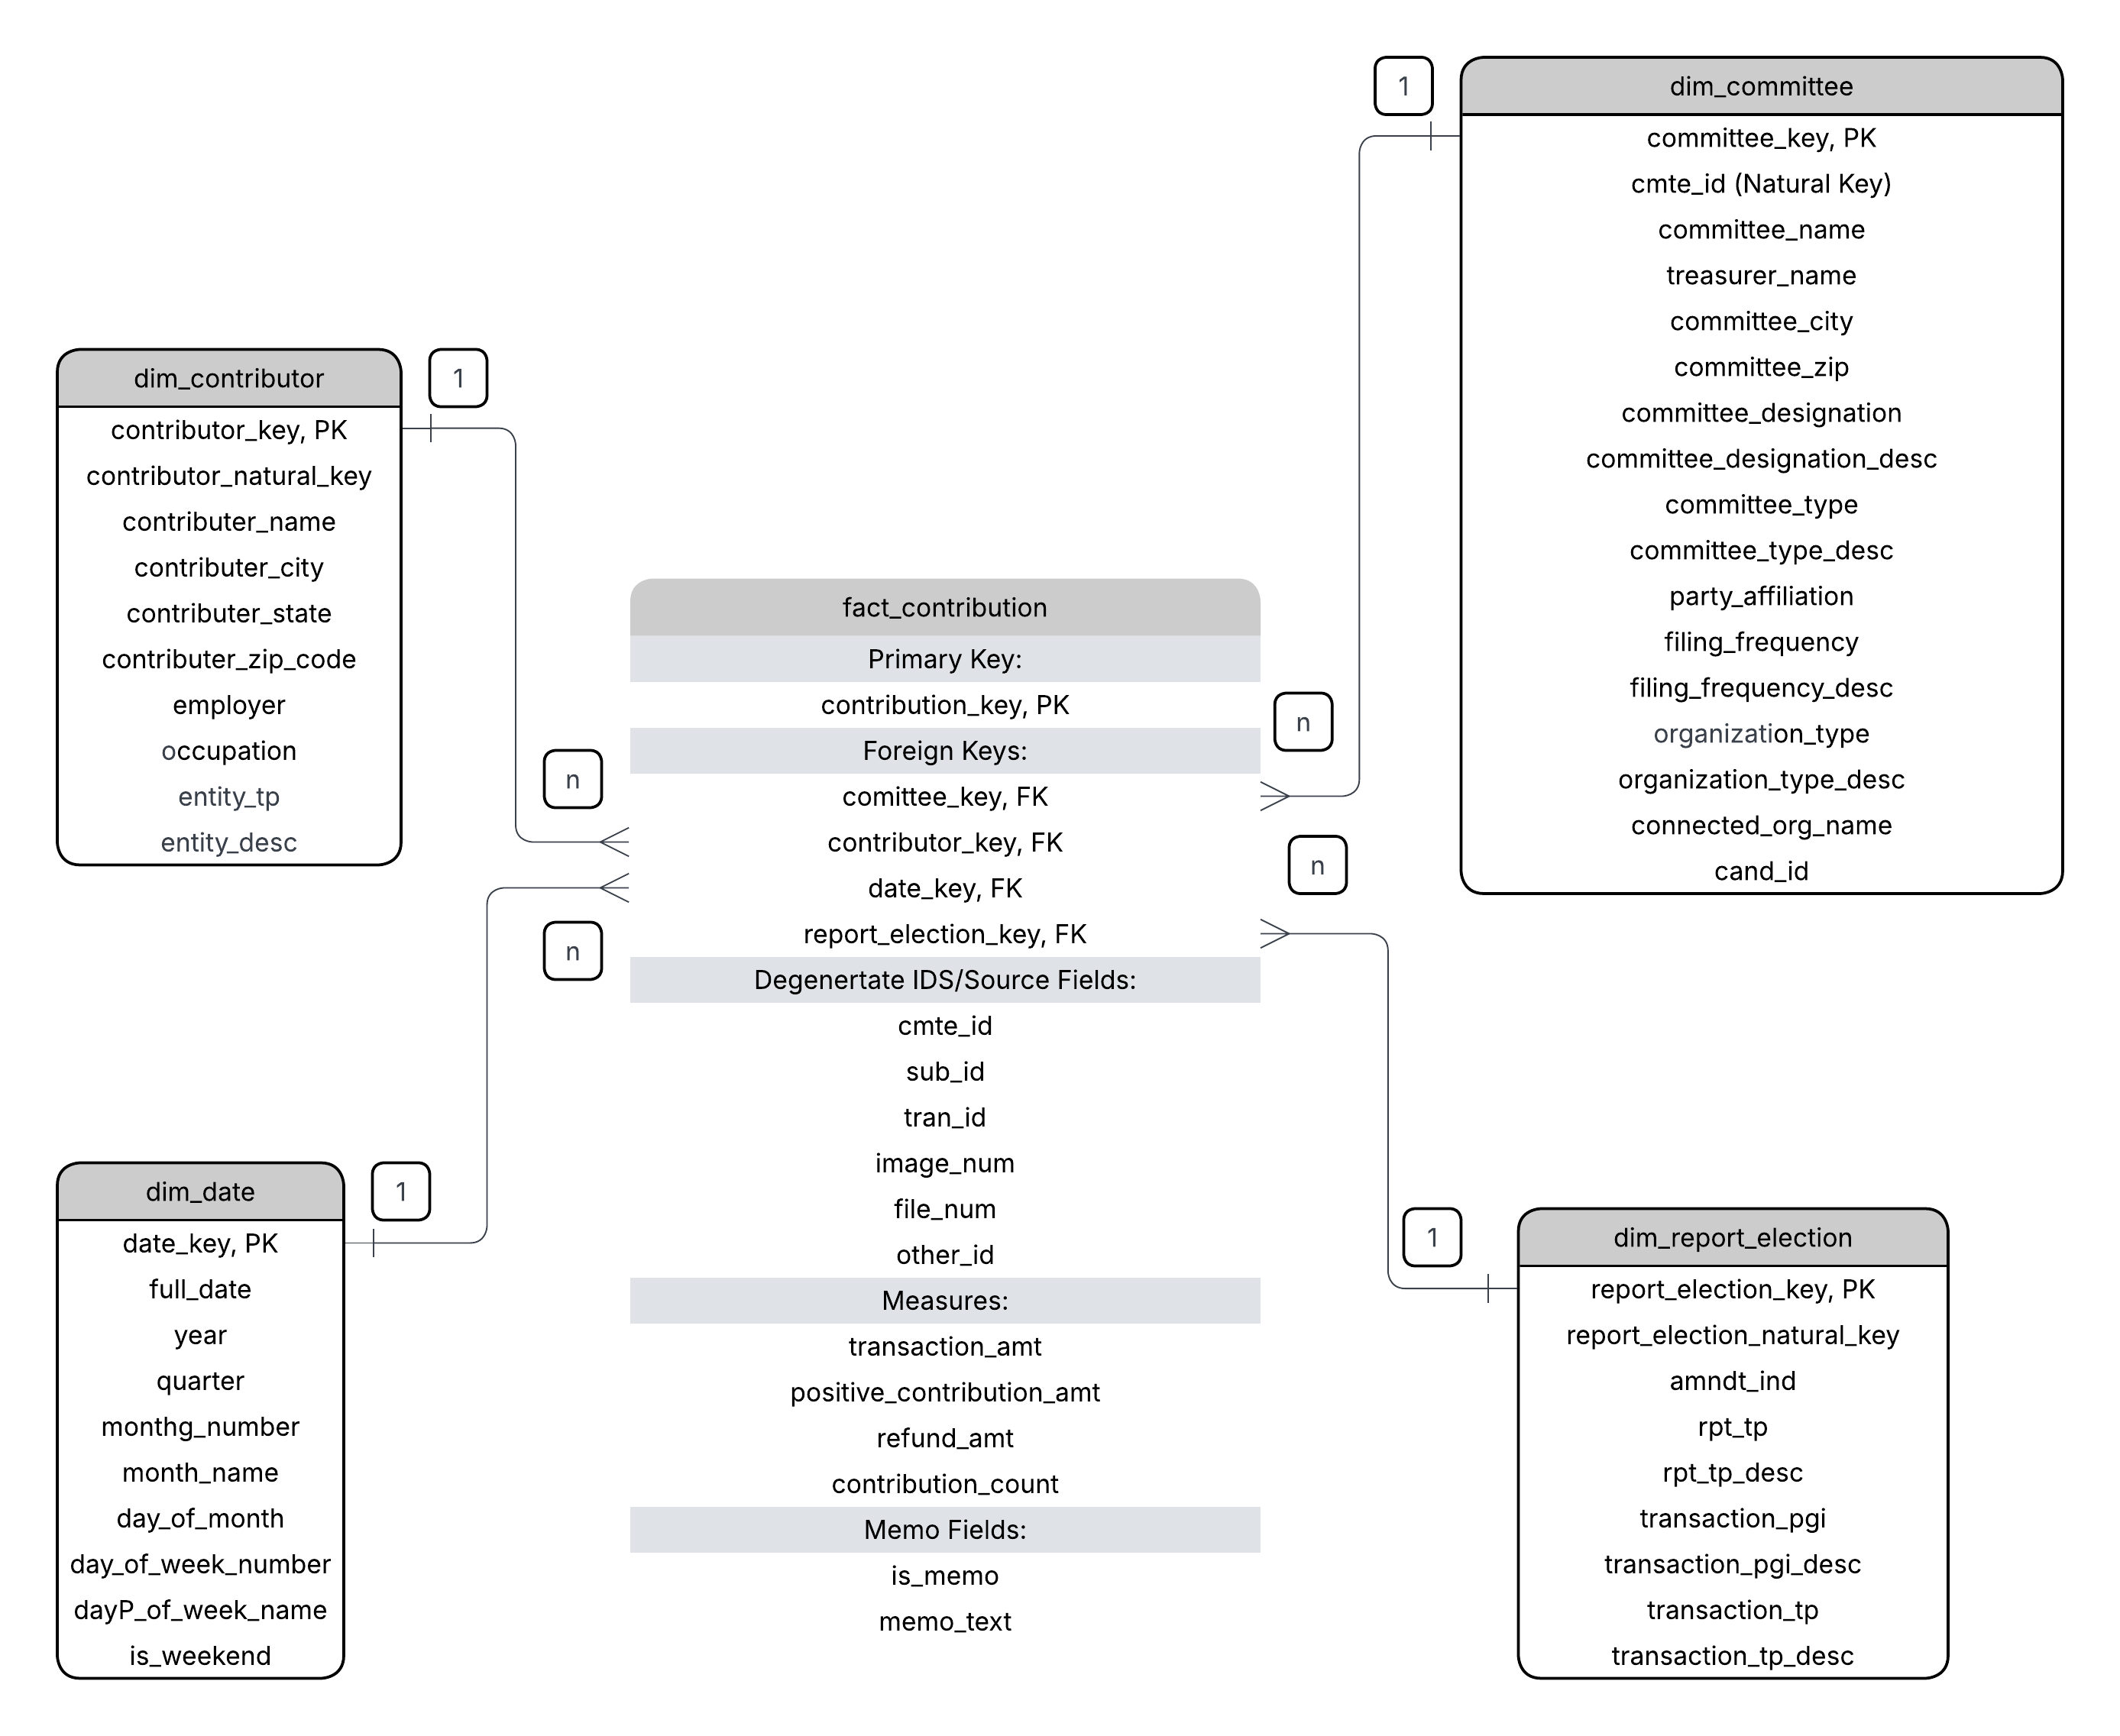

## Star Schema Design and Key Modeling Decisions

The warehouse follows the same class pattern used in the bikeshare star schema example: descriptive attributes are separated into dimension tables with surrogate keys, and the transaction-level fact table stores measures plus foreign keys to those dimensions.

Fact table:
- `fact_contribution`

Dimensions:
- `dim_committee`
- `dim_contributor`
- `dim_date`
- `dim_report_election`

The `dim_report_election` table is intentionally used as a combined Report/Election/Transaction Type dimension. It groups report type, election indicator, amendment indicator, and transaction type codes into one smaller code dimension instead of leaving all of those descriptive codes in the fact table.

Degenerate transaction identifiers kept in the fact table:
- `cmte_id`
- `sub_id`
- `tran_id`
- `image_num`
- `file_num`

These identifiers are kept in the fact table because they describe the original transaction or filing record and can help trace a warehouse row back to the raw FEC source. They are not separate dimensions in this model.

The fact grain is **one row per individual contribution transaction**. Memo rows are not deleted; instead, the notebook keeps them with an `is_memo` flag and filters them out in the analysis queries when the goal is to measure positive contribution totals.

Missing values are standardized to `UNKNOWN` or `NONE` so SQL grouping does not split blanks, NULLs, and missing categories into separate results. The contributor natural key is a constructed MD5 key, not a true source-system natural key. This is an assumption made because the FEC individual contribution file does not provide one stable contributor id. The report/election natural key is also constructed with MD5 from the combined report, election, amendment, and transaction type fields. Committee ids that appear in the contribution file but not in the committee master file are kept by adding placeholder committee rows, which prevents unmatched transactions from being dropped during fact table loading.


In [ ]:
%%sql
-- Create and populate the clean contribution table. The SELECT below standardizes text, decodes codes, converts dates, and creates amount measures.
DROP TABLE IF EXISTS clean_individual_contributions CASCADE;

CREATE TABLE clean_individual_contributions (
    cmte_id TEXT,
    amndt_ind TEXT,
    rpt_tp TEXT,
    rpt_tp_desc TEXT,
    transaction_pgi TEXT,
    transaction_pgi_desc TEXT,
    image_num TEXT,
    transaction_tp TEXT,
    transaction_tp_desc TEXT,
    entity_tp TEXT,
    entity_desc TEXT,
    contributor_name TEXT,
    contributor_city TEXT,
    contributor_state TEXT,
    contributor_zip_code TEXT,
    employer TEXT,
    occupation TEXT,
    transaction_date DATE,
    date_key INTEGER,
    transaction_amt NUMERIC(14,2),
    positive_contribution_amt NUMERIC(14,2),
    refund_amt NUMERIC(14,2),
    other_id TEXT,
    tran_id TEXT,
    file_num TEXT,
    memo_cd TEXT,
    is_memo BOOLEAN,
    memo_text TEXT,
    sub_id TEXT
);

INSERT INTO clean_individual_contributions (
    cmte_id,
    amndt_ind,
    rpt_tp,
    rpt_tp_desc,
    transaction_pgi,
    transaction_pgi_desc,
    image_num,
    transaction_tp,
    transaction_tp_desc,
    entity_tp,
    entity_desc,
    contributor_name,
    contributor_city,
    contributor_state,
    contributor_zip_code,
    employer,
    occupation,
    transaction_date,
    date_key,
    transaction_amt,
    positive_contribution_amt,
    refund_amt,
    other_id,
    tran_id,
    file_num,
    memo_cd,
    is_memo,
    memo_text,
    sub_id
)
SELECT
    -- COALESCE + NULLIF turns blanks into UNKNOWN after trimming and uppercasing.
    COALESCE(NULLIF(UPPER(TRIM(cmte_id)), ''), 'UNKNOWN') AS cmte_id,
    COALESCE(NULLIF(UPPER(TRIM(amndt_ind)), ''), 'UNKNOWN') AS amndt_ind,
    COALESCE(NULLIF(UPPER(TRIM(rpt_tp)), ''), 'UNKNOWN') AS rpt_tp,
    -- CASE decodes FEC report type codes into readable labels.
    CASE COALESCE(NULLIF(UPPER(TRIM(rpt_tp)), ''), 'UNKNOWN')
        WHEN 'M1' THEN 'January Monthly'
        WHEN 'M2' THEN 'February Monthly'
        WHEN 'M3' THEN 'March Monthly'
        WHEN 'M4' THEN 'April Monthly'
        WHEN 'M5' THEN 'May Monthly'
        WHEN 'M6' THEN 'June Monthly'
        WHEN 'M7' THEN 'July Monthly'
        WHEN 'M8' THEN 'August Monthly'
        WHEN 'M9' THEN 'September Monthly'
        WHEN 'M10' THEN 'October Monthly'
        WHEN 'M11' THEN 'November Monthly'
        WHEN 'M12' THEN 'December Monthly'
        WHEN 'Q1' THEN 'April Quarterly'
        WHEN 'Q2' THEN 'July Quarterly'
        WHEN 'Q3' THEN 'October Quarterly'
        WHEN 'YE' THEN 'Year End'
        ELSE 'Other or Unknown'
    END AS rpt_tp_desc,
    COALESCE(NULLIF(UPPER(TRIM(transaction_pgi)), ''), 'UNKNOWN') AS transaction_pgi,
    CASE COALESCE(NULLIF(UPPER(TRIM(transaction_pgi)), ''), 'UNKNOWN')
        WHEN 'P' THEN 'Primary'
        WHEN 'G' THEN 'General'
        WHEN 'O' THEN 'Other'
        WHEN 'C' THEN 'Convention'
        WHEN 'R' THEN 'Runoff'
        WHEN 'S' THEN 'Special'
        WHEN 'E' THEN 'Recount'
        ELSE 'Other or Unknown'
    END AS transaction_pgi_desc,
    NULLIF(TRIM(image_num), '') AS image_num,
    COALESCE(NULLIF(UPPER(TRIM(transaction_tp)), ''), 'UNKNOWN') AS transaction_tp,
    CASE COALESCE(NULLIF(UPPER(TRIM(transaction_tp)), ''), 'UNKNOWN')
        WHEN '10' THEN 'Contribution to committee'
        WHEN '11' THEN 'Individual contribution'
        WHEN '15' THEN 'Contribution'
        WHEN '15E' THEN 'Earmarked contribution'
        WHEN '22Y' THEN 'Refund'
        ELSE 'Other or Unknown'
    END AS transaction_tp_desc,
    COALESCE(NULLIF(UPPER(TRIM(entity_tp)), ''), 'UNKNOWN') AS entity_tp,
    CASE COALESCE(NULLIF(UPPER(TRIM(entity_tp)), ''), 'UNKNOWN')
        WHEN 'CAN' THEN 'Candidate'
        WHEN 'CCM' THEN 'Candidate Committee'
        WHEN 'COM' THEN 'Committee'
        WHEN 'IND' THEN 'Individual'
        WHEN 'ORG' THEN 'Organization'
        WHEN 'PAC' THEN 'Political Action Committee'
        WHEN 'PTY' THEN 'Party Organization'
        ELSE 'Unknown'
    END AS entity_desc,
    COALESCE(NULLIF(UPPER(TRIM(name)), ''), 'UNKNOWN') AS contributor_name,
    COALESCE(NULLIF(UPPER(TRIM(city)), ''), 'UNKNOWN') AS contributor_city,
    COALESCE(NULLIF(UPPER(TRIM(state)), ''), 'UNKNOWN') AS contributor_state,
    COALESCE(NULLIF(TRIM(zip_code), ''), 'UNKNOWN') AS contributor_zip_code,
    COALESCE(NULLIF(UPPER(TRIM(employer)), ''), 'UNKNOWN') AS employer,
    COALESCE(NULLIF(UPPER(TRIM(occupation)), ''), 'UNKNOWN') AS occupation,
    -- Convert the MMDDYYYY text date into a SQL DATE when the raw value is usable.
    CASE
        WHEN transaction_dt IS NOT NULL
         AND TRIM(transaction_dt) <> ''
         AND LENGTH(TRIM(transaction_dt)) = 8
        THEN TO_DATE(TRIM(transaction_dt), 'MMDDYYYY')
        ELSE NULL
    END AS transaction_date,
    CASE
        WHEN transaction_dt IS NOT NULL
         AND TRIM(transaction_dt) <> ''
         AND LENGTH(TRIM(transaction_dt)) = 8
        THEN CAST(TO_CHAR(TO_DATE(TRIM(transaction_dt), 'MMDDYYYY'), 'YYYYMMDD') AS INTEGER)
        ELSE -1
    END AS date_key,
    CAST(COALESCE(NULLIF(TRIM(transaction_amt), ''), '0') AS NUMERIC(14,2)) AS transaction_amt,
    -- Split the amount into positive contribution dollars and refund dollars for analysis.
    CASE
        WHEN CAST(COALESCE(NULLIF(TRIM(transaction_amt), ''), '0') AS NUMERIC(14,2)) > 0
        THEN CAST(COALESCE(NULLIF(TRIM(transaction_amt), ''), '0') AS NUMERIC(14,2))
        ELSE 0
    END AS positive_contribution_amt,
    CASE
        WHEN CAST(COALESCE(NULLIF(TRIM(transaction_amt), ''), '0') AS NUMERIC(14,2)) < 0
        THEN ABS(CAST(COALESCE(NULLIF(TRIM(transaction_amt), ''), '0') AS NUMERIC(14,2)))
        ELSE 0
    END AS refund_amt,
    NULLIF(UPPER(TRIM(other_id)), '') AS other_id,
    COALESCE(NULLIF(TRIM(tran_id), ''), 'UNKNOWN') AS tran_id,
    NULLIF(TRIM(file_num), '') AS file_num,
    NULLIF(UPPER(TRIM(memo_cd)), '') AS memo_cd,
    -- Keep memo rows but flag them so analysis queries can filter them out.
    CASE
        WHEN UPPER(NULLIF(TRIM(memo_cd), '')) = 'X' THEN TRUE
        ELSE FALSE
    END AS is_memo,
    NULLIF(TRIM(memo_text), '') AS memo_text,
    COALESCE(NULLIF(TRIM(sub_id), ''), 'UNKNOWN') AS sub_id
FROM raw_individual_contributions;


Running query in 'postgresql://student@/fec_project'

26323444 rows affected.

++
||
++
++

This code creates and fills the cleaned contribution table. It standardizes text fields, decodes common FEC codes with CASE statements, converts the transaction date into a DATE and date_key, converts amounts into numeric measures, and keeps memo rows with an is_memo flag.


In [ ]:
%%sql
-- Create and populate the clean committee table. The SELECT below standardizes committee fields and decodes FEC committee codes.
DROP TABLE IF EXISTS clean_committee CASCADE;

CREATE TABLE clean_committee (
    cmte_id TEXT,
    committee_name TEXT,
    treasurer_name TEXT,
    committee_street_1 TEXT,
    committee_street_2 TEXT,
    committee_city TEXT,
    committee_state TEXT,
    committee_zip TEXT,
    committee_designation TEXT,
    committee_designation_desc TEXT,
    committee_type TEXT,
    committee_type_desc TEXT,
    party_affiliation TEXT,
    filing_frequency TEXT,
    filing_frequency_desc TEXT,
    organization_type TEXT,
    organization_type_desc TEXT,
    connected_org_name TEXT,
    cand_id TEXT
);

INSERT INTO clean_committee (
    cmte_id,
    committee_name,
    treasurer_name,
    committee_street_1,
    committee_street_2,
    committee_city,
    committee_state,
    committee_zip,
    committee_designation,
    committee_designation_desc,
    committee_type,
    committee_type_desc,
    party_affiliation,
    filing_frequency,
    filing_frequency_desc,
    organization_type,
    organization_type_desc,
    connected_org_name,
    cand_id
)
SELECT
    -- COALESCE + NULLIF standardizes missing committee fields to UNKNOWN or NONE.
    COALESCE(NULLIF(UPPER(TRIM(cmte_id)), ''), 'UNKNOWN') AS cmte_id,
    COALESCE(NULLIF(UPPER(TRIM(cmte_nm)), ''), 'UNKNOWN') AS committee_name,
    COALESCE(NULLIF(UPPER(TRIM(tres_nm)), ''), 'UNKNOWN') AS treasurer_name,
    COALESCE(NULLIF(UPPER(TRIM(cmte_st1)), ''), 'UNKNOWN') AS committee_street_1,
    COALESCE(NULLIF(UPPER(TRIM(cmte_st2)), ''), 'NONE') AS committee_street_2,
    COALESCE(NULLIF(UPPER(TRIM(cmte_city)), ''), 'UNKNOWN') AS committee_city,
    COALESCE(NULLIF(UPPER(TRIM(cmte_st)), ''), 'UNKNOWN') AS committee_state,
    COALESCE(NULLIF(TRIM(cmte_zip), ''), 'UNKNOWN') AS committee_zip,
    COALESCE(NULLIF(UPPER(TRIM(cmte_dsgn)), ''), 'UNKNOWN') AS committee_designation,
    -- CASE decodes committee designation codes into readable descriptions.
    CASE COALESCE(NULLIF(UPPER(TRIM(cmte_dsgn)), ''), 'UNKNOWN')
        WHEN 'A' THEN 'Authorized by Candidate'
        WHEN 'B' THEN 'Lobbyist/Registrant PAC'
        WHEN 'D' THEN 'Leadership PAC'
        WHEN 'J' THEN 'Joint Fund Raiser'
        WHEN 'P' THEN 'Principal Campaign Committee'
        WHEN 'U' THEN 'Unauthorized'
        ELSE 'Other or Unknown'
    END AS committee_designation_desc,
    COALESCE(NULLIF(UPPER(TRIM(cmte_tp)), ''), 'UNKNOWN') AS committee_type,
    CASE COALESCE(NULLIF(UPPER(TRIM(cmte_tp)), ''), 'UNKNOWN')
        WHEN 'C' THEN 'Communication Cost'
        WHEN 'D' THEN 'Delegate'
        WHEN 'E' THEN 'Electioneering Communication'
        WHEN 'H' THEN 'House'
        WHEN 'I' THEN 'Independent Expenditure Only'
        WHEN 'N' THEN 'PAC - Nonqualified'
        WHEN 'O' THEN 'Independent Expenditure - Nonqualified'
        WHEN 'P' THEN 'Presidential'
        WHEN 'Q' THEN 'PAC - Qualified'
        WHEN 'S' THEN 'Senate'
        WHEN 'X' THEN 'Party - Nonqualified'
        WHEN 'Y' THEN 'Party - Qualified'
        WHEN 'Z' THEN 'National Party Organization'
        ELSE 'Other or Unknown'
    END AS committee_type_desc,
    COALESCE(NULLIF(UPPER(TRIM(cmte_pty_affiliation)), ''), 'UNKNOWN') AS party_affiliation,
    COALESCE(NULLIF(UPPER(TRIM(cmte_filing_freq)), ''), 'UNKNOWN') AS filing_frequency,
    CASE COALESCE(NULLIF(UPPER(TRIM(cmte_filing_freq)), ''), 'UNKNOWN')
        WHEN 'A' THEN 'Administratively Terminated'
        WHEN 'D' THEN 'Debt'
        WHEN 'M' THEN 'Monthly'
        WHEN 'Q' THEN 'Quarterly'
        WHEN 'T' THEN 'Terminated'
        WHEN 'W' THEN 'Waived'
        ELSE 'Other or Unknown'
    END AS filing_frequency_desc,
    COALESCE(NULLIF(UPPER(TRIM(org_tp)), ''), 'UNKNOWN') AS organization_type,
    CASE COALESCE(NULLIF(UPPER(TRIM(org_tp)), ''), 'UNKNOWN')
        WHEN 'C' THEN 'Corporation'
        WHEN 'L' THEN 'Labor Organization'
        WHEN 'M' THEN 'Membership Organization'
        WHEN 'T' THEN 'Trade Association'
        WHEN 'V' THEN 'Cooperative'
        WHEN 'W' THEN 'Corporation Without Capital Stock'
        ELSE 'Other or Unknown'
    END AS organization_type_desc,
    COALESCE(NULLIF(UPPER(TRIM(connected_org_nm)), ''), 'NONE') AS connected_org_name,
    COALESCE(NULLIF(UPPER(TRIM(cand_id)), ''), 'NONE') AS cand_id
FROM raw_committee;


Running query in 'postgresql://student@/fec_project'

20941 rows affected.

++
||
++
++

This code creates and fills the cleaned committee table. It standardizes committee names and locations, decodes committee-related codes, and uses UNKNOWN or NONE for missing descriptive values so later GROUP BY queries are cleaner.


In [ ]:
%%sql
-- Document the clean tables so it is clear these are the SQL-cleaned staging tables used for the warehouse.
COMMENT ON TABLE clean_individual_contributions IS
'Cleaned contribution transactions with standardized codes, dates, amounts, and memo flag.';

COMMENT ON TABLE clean_committee IS
'Cleaned committee master records with decoded committee attributes.';


Running query in 'postgresql://student@/fec_project'

++
||
++
++

These comments document the clean tables. They make it clear that these tables are the cleaned versions used to build the warehouse tables.


In [ ]:
%%sql
-- Compare row counts for the two clean tables after transformation.
SELECT 'clean_individual_contributions' AS table_name, COUNT(*) AS row_count
FROM clean_individual_contributions

UNION ALL

SELECT 'clean_committee' AS table_name, COUNT(*) AS row_count
FROM clean_committee;


Running query in 'postgresql://student@/fec_project'

2 rows affected.

table_name,row_count
clean_individual_contributions,26323444
clean_committee,20941


This validation confirms that the cleaned contribution and committee tables were successfully created and populated after the transformation process. The cleaned contribution table preserves all 26,323,444 transaction-level records, while the cleaned committee table contains 20,941 standardized committee records used to build the warehouse dimensions.

This count check confirms that the clean contribution and clean committee tables were created and populated. It is a basic row-count validation after the cleaning step.


In [ ]:
%%sql
-- Preview cleaned date and amount measures to verify type conversion and refund logic.
SELECT
    transaction_date,
    date_key,
    transaction_amt,
    positive_contribution_amt,
    refund_amt,
    is_memo
FROM clean_individual_contributions
LIMIT 10;


Running query in 'postgresql://student@/fec_project'

10 rows affected.

transaction_date,date_key,transaction_amt,positive_contribution_amt,refund_amt,is_memo
2024-06-20,20240620,400.00,400.00,0.00,False
2024-06-20,20240620,125.00,125.00,0.00,False
2024-06-20,20240620,150.00,150.00,0.00,False
2024-06-20,20240620,100.00,100.00,0.00,False
2024-06-20,20240620,100.00,100.00,0.00,False
2024-06-20,20240620,1500.00,1500.00,0.00,False
2024-06-20,20240620,500.00,500.00,0.00,False
2024-06-20,20240620,100.00,100.00,0.00,False
2024-06-20,20240620,500.00,500.00,0.00,False
2024-06-20,20240620,100.00,100.00,0.00,False


This preview checks the cleaned date and amount fields. It lets us see that transaction amounts were split into positive contribution and refund measures correctly.


In [ ]:
%%sql
-- Drop warehouse tables before rebuilding. Fact is dropped first because it references the dimensions.
DROP TABLE IF EXISTS fact_contribution CASCADE;
DROP TABLE IF EXISTS dim_report_election CASCADE;
DROP TABLE IF EXISTS dim_contributor CASCADE;
DROP TABLE IF EXISTS dim_date CASCADE;
DROP TABLE IF EXISTS dim_committee CASCADE;


Running query in 'postgresql://student@/fec_project'

++
||
++
++

This reset cell drops the warehouse tables before rebuilding them. The fact table is dropped first because it has foreign keys pointing to the dimension tables.


### dim_committee


In [ ]:
%%sql
-- Build dim_committee by grouping cleaned committee records to one row per committee id.
CREATE TABLE dim_committee (
    committee_key SERIAL PRIMARY KEY,
    cmte_id TEXT NOT NULL UNIQUE,
    committee_name TEXT NOT NULL,
    treasurer_name TEXT NOT NULL,
    committee_city TEXT NOT NULL,
    committee_state TEXT NOT NULL,
    committee_zip TEXT NOT NULL,
    committee_designation TEXT NOT NULL,
    committee_designation_desc TEXT NOT NULL,
    committee_type TEXT NOT NULL,
    committee_type_desc TEXT NOT NULL,
    party_affiliation TEXT NOT NULL,
    filing_frequency TEXT NOT NULL,
    filing_frequency_desc TEXT NOT NULL,
    organization_type TEXT NOT NULL,
    organization_type_desc TEXT NOT NULL,
    connected_org_name TEXT NOT NULL,
    cand_id TEXT NOT NULL
);

INSERT INTO dim_committee (
    cmte_id,
    committee_name,
    treasurer_name,
    committee_city,
    committee_state,
    committee_zip,
    committee_designation,
    committee_designation_desc,
    committee_type,
    committee_type_desc,
    party_affiliation,
    filing_frequency,
    filing_frequency_desc,
    organization_type,
    organization_type_desc,
    connected_org_name,
    cand_id
)
SELECT
    cmte_id,
    MAX(committee_name) AS committee_name,
    MAX(treasurer_name) AS treasurer_name,
    MAX(committee_city) AS committee_city,
    MAX(committee_state) AS committee_state,
    MAX(committee_zip) AS committee_zip,
    MAX(committee_designation) AS committee_designation,
    MAX(committee_designation_desc) AS committee_designation_desc,
    MAX(committee_type) AS committee_type,
    MAX(committee_type_desc) AS committee_type_desc,
    MAX(party_affiliation) AS party_affiliation,
    MAX(filing_frequency) AS filing_frequency,
    MAX(filing_frequency_desc) AS filing_frequency_desc,
    MAX(organization_type) AS organization_type,
    MAX(organization_type_desc) AS organization_type_desc,
    MAX(connected_org_name) AS connected_org_name,
    MAX(cand_id) AS cand_id
FROM clean_committee
GROUP BY cmte_id;


Running query in 'postgresql://student@/fec_project'

20941 rows affected.

++
||
++
++

This code builds the committee dimension. The surrogate key is committee_key, while cmte_id stays as the natural key from the FEC data. The INSERT groups by committee id so each committee appears once in the dimension.


The contribution file can contain committee ids that are not found in the
committee master file. These are preserved by adding placeholder dimension
rows, so no contribution transaction is lost when the fact table is loaded.


In [ ]:
%%sql
-- Add placeholder committee rows for contribution committee ids that were not found in the committee master file.
INSERT INTO dim_committee (
    cmte_id,
    committee_name,
    treasurer_name,
    committee_city,
    committee_state,
    committee_zip,
    committee_designation,
    committee_designation_desc,
    committee_type,
    committee_type_desc,
    party_affiliation,
    filing_frequency,
    filing_frequency_desc,
    organization_type,
    organization_type_desc,
    connected_org_name,
    cand_id
)
SELECT DISTINCT
    i.cmte_id,
    'UNKNOWN' AS committee_name,
    'UNKNOWN' AS treasurer_name,
    'UNKNOWN' AS committee_city,
    'UNKNOWN' AS committee_state,
    'UNKNOWN' AS committee_zip,
    'UNKNOWN' AS committee_designation,
    'Other or Unknown' AS committee_designation_desc,
    'UNKNOWN' AS committee_type,
    'Other or Unknown' AS committee_type_desc,
    'UNKNOWN' AS party_affiliation,
    'UNKNOWN' AS filing_frequency,
    'Other or Unknown' AS filing_frequency_desc,
    'UNKNOWN' AS organization_type,
    'Other or Unknown' AS organization_type_desc,
    'NONE' AS connected_org_name,
    'NONE' AS cand_id
FROM clean_individual_contributions i
LEFT JOIN dim_committee d
    ON i.cmte_id = d.cmte_id
WHERE d.cmte_id IS NULL;


Running query in 'postgresql://student@/fec_project'

1 rows affected.

++
||
++
++

This cell adds placeholder committee dimension rows for committee ids found in contributions but missing from the committee master file. This keeps the fact table at the full transaction grain without losing unmatched contribution rows.


In [ ]:
%%sql
-- Document committee dimension keys and meaning.
COMMENT ON TABLE dim_committee IS
'Committee dimension. Grain is one row per committee id.';

COMMENT ON COLUMN dim_committee.committee_key IS
'Surrogate key for the committee dimension.';

COMMENT ON COLUMN dim_committee.cmte_id IS
'Natural key from the FEC committee master file.';


Running query in 'postgresql://student@/fec_project'

++
||
++
++

These comments document the committee dimension and explain the difference between the surrogate key and the FEC natural key.


### dim_date


In [ ]:
%%sql
-- Build dim_date from unique transaction dates and add a -1 row for unknown dates.
CREATE TABLE dim_date (
    date_key INTEGER PRIMARY KEY,
    full_date DATE,
    year INTEGER,
    quarter INTEGER,
    month_number INTEGER,
    month_name TEXT,
    day_of_month INTEGER,
    day_of_week_number INTEGER,
    day_of_week_name TEXT,
    is_weekend BOOLEAN
);

INSERT INTO dim_date (
    date_key,
    full_date,
    year,
    quarter,
    month_number,
    month_name,
    day_of_month,
    day_of_week_number,
    day_of_week_name,
    is_weekend
)
SELECT DISTINCT
    -- TO_CHAR pulls year, quarter, month, and day parts out of each transaction date.
    date_key,
    transaction_date AS full_date,
    CAST(TO_CHAR(transaction_date, 'YYYY') AS INTEGER) AS year,
    CAST(TO_CHAR(transaction_date, 'Q') AS INTEGER) AS quarter,
    CAST(TO_CHAR(transaction_date, 'MM') AS INTEGER) AS month_number,
    TRIM(TO_CHAR(transaction_date, 'Month')) AS month_name,
    CAST(TO_CHAR(transaction_date, 'DD') AS INTEGER) AS day_of_month,
    CAST(TO_CHAR(transaction_date, 'D') AS INTEGER) AS day_of_week_number,
    TRIM(TO_CHAR(transaction_date, 'Day')) AS day_of_week_name,
    CASE
        WHEN CAST(TO_CHAR(transaction_date, 'D') AS INTEGER) IN (1, 7)
        THEN TRUE
        ELSE FALSE
    END AS is_weekend
FROM clean_individual_contributions
WHERE transaction_date IS NOT NULL;

INSERT INTO dim_date (
    date_key,
    full_date,
    year,
    quarter,
    month_number,
    month_name,
    day_of_month,
    day_of_week_number,
    day_of_week_name,
    is_weekend
)
VALUES (
    -1,
    NULL,
    NULL,
    NULL,
    NULL,
    'Unknown',
    NULL,
    NULL,
    'Unknown',
    FALSE
);


Running query in 'postgresql://student@/fec_project'

138 rows affected.

1 rows affected.

++
||
++
++

This code builds the date dimension from transaction dates. The date_key uses YYYYMMDD for real dates, and a -1 row is added for unknown dates so every fact row can still join to a date record.


In [ ]:
%%sql
-- Document the date key convention, including -1 for unknown dates.
COMMENT ON TABLE dim_date IS
'Date dimension using YYYYMMDD date_key, with -1 for unknown dates.';

COMMENT ON COLUMN dim_date.date_key IS
'Natural date key in YYYYMMDD format. Unknown dates use -1.';


Running query in 'postgresql://student@/fec_project'

++
||
++
++

These comments describe the date dimension and note the special -1 key used for unknown transaction dates.


### dim_contributor


In [ ]:
%%sql
-- Build dim_contributor. MD5 turns the combined contributor attributes into one constructed natural key.
CREATE TABLE dim_contributor (
    contributor_key SERIAL PRIMARY KEY,
    contributor_natural_key TEXT NOT NULL UNIQUE,
    contributor_name TEXT NOT NULL,
    contributor_city TEXT NOT NULL,
    contributor_state TEXT NOT NULL,
    contributor_zip_code TEXT NOT NULL,
    employer TEXT NOT NULL,
    occupation TEXT NOT NULL,
    entity_tp TEXT NOT NULL,
    entity_desc TEXT NOT NULL
);

INSERT INTO dim_contributor (
    contributor_natural_key,
    contributor_name,
    contributor_city,
    contributor_state,
    contributor_zip_code,
    employer,
    occupation,
    entity_tp,
    entity_desc
)
SELECT DISTINCT
    -- MD5 turns the combined contributor profile fields into one repeatable key.
    -- This is needed because the FEC file does not provide one contributor id.
    MD5(
        contributor_name || '|' ||
        contributor_city || '|' ||
        contributor_state || '|' ||
        contributor_zip_code || '|' ||
        employer || '|' ||
        occupation || '|' ||
        entity_tp
    ) AS contributor_natural_key,
    contributor_name,
    contributor_city,
    contributor_state,
    contributor_zip_code,
    employer,
    occupation,
    entity_tp,
    entity_desc
FROM clean_individual_contributions;


Running query in 'postgresql://student@/fec_project'

4956972 rows affected.

++
||
++
++

This code builds the contributor dimension. Since the FEC file does not give one stable contributor id, the notebook creates a natural key from the cleaned contributor fields and stores a separate SERIAL surrogate key for joins.


In [ ]:
%%sql
-- Document contributor dimension keys, including the constructed MD5 natural key.
COMMENT ON TABLE dim_contributor IS
'Contributor dimension. Grain is one unique contributor profile.';

COMMENT ON COLUMN dim_contributor.contributor_key IS
'Surrogate key for contributor joins.';

COMMENT ON COLUMN dim_contributor.contributor_natural_key IS
'MD5 natural key built from cleaned contributor attributes.';


Running query in 'postgresql://student@/fec_project'

++
||
++
++

These comments document the contributor dimension and explain why the contributor natural key is built from contributor attributes.


### dim_report_election: Report/Election/Transaction Type Dimension


In [ ]:
%%sql
-- Build the combined Report/Election/Transaction Type dimension from distinct report and transaction code combinations.
CREATE TABLE dim_report_election (
    report_election_key SERIAL PRIMARY KEY,
    report_election_natural_key TEXT NOT NULL UNIQUE,
    amndt_ind TEXT NOT NULL,
    rpt_tp TEXT NOT NULL,
    rpt_tp_desc TEXT NOT NULL,
    transaction_pgi TEXT NOT NULL,
    transaction_pgi_desc TEXT NOT NULL,
    transaction_tp TEXT NOT NULL,
    transaction_tp_desc TEXT NOT NULL
);

INSERT INTO dim_report_election (
    report_election_natural_key,
    amndt_ind,
    rpt_tp,
    rpt_tp_desc,
    transaction_pgi,
    transaction_pgi_desc,
    transaction_tp,
    transaction_tp_desc
)
SELECT DISTINCT
    -- MD5 turns the combined report/election/transaction codes into one repeatable key.
    -- This dimension is identified by a combination of code fields.
    MD5(
        amndt_ind || '|' ||
        rpt_tp || '|' ||
        transaction_pgi || '|' ||
        transaction_tp
    ) AS report_election_natural_key,
    amndt_ind,
    rpt_tp,
    rpt_tp_desc,
    transaction_pgi,
    transaction_pgi_desc,
    transaction_tp,
    transaction_tp_desc
FROM clean_individual_contributions;


Running query in 'postgresql://student@/fec_project'

993 rows affected.

++
||
++
++

This code builds the Report/Election/Transaction Type dimension. It separates report type, amendment indicator, election indicator, and transaction type details from the fact table. This makes the dimension work like a small combined code dimension while keeping the fact table focused on transaction measures and keys.


In [ ]:
%%sql
-- Document the report/election/transaction type dimension and its constructed natural key.
COMMENT ON TABLE dim_report_election IS
'Report and election dimension. Grain is one unique report/election/transaction code combination.';

COMMENT ON COLUMN dim_report_election.report_election_key IS
'Surrogate key for report and election joins.';

COMMENT ON COLUMN dim_report_election.report_election_natural_key IS
'MD5 natural key built from report, election, amendment, and transaction type codes.';


Running query in 'postgresql://student@/fec_project'

++
||
++
++

These comments document the report/election dimension and the natural key made from the related report and election fields.


In [ ]:
%%sql
-- Create the fact table. It stores one row per contribution transaction plus dimension foreign keys and contribution measures.
CREATE TABLE fact_contribution (
    contribution_key BIGSERIAL PRIMARY KEY,
    committee_key INTEGER NOT NULL,
    contributor_key INTEGER NOT NULL,
    date_key INTEGER NOT NULL,
    report_election_key INTEGER NOT NULL,
    cmte_id TEXT NOT NULL,
    sub_id TEXT NOT NULL,
    tran_id TEXT NOT NULL,
    image_num TEXT,
    file_num TEXT,
    other_id TEXT,
    transaction_amt NUMERIC(14,2) NOT NULL,
    positive_contribution_amt NUMERIC(14,2) NOT NULL,
    refund_amt NUMERIC(14,2) NOT NULL,
    contribution_count INTEGER NOT NULL DEFAULT 1,
    is_memo BOOLEAN NOT NULL DEFAULT FALSE,
    memo_text TEXT,
    CONSTRAINT fk_fact_committee
        FOREIGN KEY (committee_key)
        REFERENCES dim_committee (committee_key),
    CONSTRAINT fk_fact_contributor
        FOREIGN KEY (contributor_key)
        REFERENCES dim_contributor (contributor_key),
    CONSTRAINT fk_fact_date
        FOREIGN KEY (date_key)
        REFERENCES dim_date (date_key),
    CONSTRAINT fk_fact_report_election
        FOREIGN KEY (report_election_key)
        REFERENCES dim_report_election (report_election_key)
);


Running query in 'postgresql://student@/fec_project'

++
||
++
++

This code creates the contribution fact table. The grain is one contribution transaction per row, with foreign keys to each dimension and measures for transaction amount, positive contributions, refunds, and contribution count. It also keeps source transaction identifiers such as `cmte_id`, `sub_id`, `tran_id`, `image_num`, and `file_num` as degenerate transaction identifiers so records can still be traced back to the FEC source data.


In [ ]:
%%sql
-- Add columns that will store precomputed MD5 keys for faster fact-table joins.
-- Add precomputed natural key columns to avoid recalculating MD5 during joins
ALTER TABLE clean_individual_contributions
ADD COLUMN IF NOT EXISTS contributor_natural_key TEXT;

ALTER TABLE clean_individual_contributions
ADD COLUMN IF NOT EXISTS report_election_natural_key TEXT;


Running query in 'postgresql://student@/fec_project'

++
||
++
++

In [ ]:
%%sql
-- Fill the contributor MD5 key once using the cleaned contributor attributes.
-- Precompute contributor natural key once instead of during join
UPDATE clean_individual_contributions
SET contributor_natural_key = MD5(
    contributor_name || '|' ||
    contributor_city || '|' ||
    contributor_state || '|' ||
    contributor_zip_code || '|' ||
    employer || '|' ||
    occupation || '|' ||
    entity_tp
)
WHERE contributor_natural_key IS NULL;


Running query in 'postgresql://student@/fec_project'

26323444 rows affected.

++
||
++
++

In [ ]:
%%sql
-- Fill the report/election MD5 key once using the cleaned report, election, amendment, and transaction type fields.
-- Precompute report/election natural key once instead of during join
UPDATE clean_individual_contributions
SET report_election_natural_key = MD5(
    amndt_ind || '|' ||
    rpt_tp || '|' ||
    transaction_pgi || '|' ||
    transaction_tp
)
WHERE report_election_natural_key IS NULL;


Running query in 'postgresql://student@/fec_project'

26323444 rows affected.

++
||
++
++

In [ ]:
%%sql
-- Index the precomputed clean-table keys so dimension joins are faster.
-- Create indexes on staging table to speed up joins
CREATE INDEX IF NOT EXISTS idx_clean_contributor_nk
    ON clean_individual_contributions (contributor_natural_key);

CREATE INDEX IF NOT EXISTS idx_clean_report_nk
    ON clean_individual_contributions (report_election_natural_key);

CREATE INDEX IF NOT EXISTS idx_clean_cmte_id
    ON clean_individual_contributions (cmte_id);

CREATE INDEX IF NOT EXISTS idx_clean_date_key
    ON clean_individual_contributions (date_key);


Running query in 'postgresql://student@/fec_project'

++
||
++
++

In [ ]:
%%sql
-- Load fact table using precomputed keys for much faster joins
INSERT INTO fact_contribution (
    committee_key,
    contributor_key,
    date_key,
    report_election_key,
    cmte_id,
    sub_id,
    tran_id,
    image_num,
    file_num,
    other_id,
    transaction_amt,
    positive_contribution_amt,
    refund_amt,
    contribution_count,
    is_memo,
    memo_text
)
SELECT
    dc.committee_key,
    dcon.contributor_key,
    dd.date_key,
    dre.report_election_key,
    c.cmte_id,
    c.sub_id,
    c.tran_id,
    c.image_num,
    c.file_num,
    c.other_id,
    c.transaction_amt,
    c.positive_contribution_amt,
    c.refund_amt,
    1 AS contribution_count,
    c.is_memo,
    c.memo_text
FROM clean_individual_contributions c
-- JOINs replace descriptive source fields with dimension surrogate keys.
JOIN dim_committee dc
    ON c.cmte_id = dc.cmte_id
JOIN dim_contributor dcon
    ON c.contributor_natural_key = dcon.contributor_natural_key
JOIN dim_date dd
    ON c.date_key = dd.date_key
JOIN dim_report_election dre
    ON c.report_election_natural_key = dre.report_election_natural_key;


Running query in 'postgresql://student@/fec_project'

26323444 rows affected.

++
||
++
++

After attempting to load we have commented this section out and implemented a quicker loading attempt. It is worth noting that we received assistance from AI tools in order to find a quicker means to producing the table load.

In [ ]:
%%sql
-- SELECT returns the specific fields needed for this check or analysis step.
-- INSERT INTO fact_contribution (
--     committee_key,
--     contributor_key,
--     date_key,
--     report_election_key,
--     cmte_id,
--     sub_id,
--     tran_id,
--     image_num,
--     file_num,
--     other_id,
--     transaction_amt,
--     positive_contribution_amt,
--     refund_amt,
--     contribution_count,
--     is_memo,
--     memo_text
-- )
-- SELECT
--     dc.committee_key,
--     dcon.contributor_key,
--     dd.date_key,
--     dre.report_election_key,
--     c.cmte_id,
--     c.sub_id,
--     c.tran_id,
--     c.image_num,
--     c.file_num,
--     c.other_id,
--     c.transaction_amt,
--     c.positive_contribution_amt,
--     c.refund_amt,
--     1 AS contribution_count,
--     c.is_memo,
--     c.memo_text
-- FROM clean_individual_contributions c
-- JOIN dim_committee dc
--     ON c.cmte_id = dc.cmte_id
-- JOIN dim_contributor dcon
--     ON MD5(
--         c.contributor_name || '|' ||
--         c.contributor_city || '|' ||
--         c.contributor_state || '|' ||
--         c.contributor_zip_code || '|' ||
--         c.employer || '|' ||
--         c.occupation || '|' ||
--         c.entity_tp
--     ) = dcon.contributor_natural_key
-- JOIN dim_date dd
--     ON c.date_key = dd.date_key
-- JOIN dim_report_election dre
--     ON MD5(
--         c.amndt_ind || '|' ||
--         c.rpt_tp || '|' ||
--         c.transaction_pgi || '|' ||
--         c.transaction_tp
--     ) = dre.report_election_natural_key;


This INSERT loads the fact table by joining the cleaned contributions to each dimension. The joins replace repeated descriptive fields with dimension keys while preserving the original transaction-level rows.


In [ ]:
%%sql
-- Document the fact table grain and measure columns.
COMMENT ON TABLE fact_contribution IS
'Fact table at one contribution transaction per row.';

COMMENT ON COLUMN fact_contribution.contribution_key IS
'Surrogate key for the contribution fact table.';

COMMENT ON COLUMN fact_contribution.transaction_amt IS
'Original transaction amount. Negative amounts are preserved.';

COMMENT ON COLUMN fact_contribution.positive_contribution_amt IS
'Positive contribution measure. Negative values are stored as zero here.';

COMMENT ON COLUMN fact_contribution.refund_amt IS
'Refund measure. Negative transaction amounts are converted to positive refund amounts.';

COMMENT ON COLUMN fact_contribution.contribution_count IS
'Additive count measure. Each transaction contributes 1.';

COMMENT ON COLUMN fact_contribution.is_memo IS
'TRUE when memo_cd is X. Memo rows are retained, not deleted.';


Running query in 'postgresql://student@/fec_project'

++
||
++
++

These comments document the fact table and its measures. This is especially important because transaction_amt, positive_contribution_amt, and refund_amt are related but mean different things.


In [ ]:
%%sql
-- Add indexes on fact-table foreign keys and analysis fields used in joins and filters.
DROP INDEX IF EXISTS idx_fact_contribution_committee_key;
DROP INDEX IF EXISTS idx_fact_contribution_contributor_key;
DROP INDEX IF EXISTS idx_fact_contribution_date_key;
DROP INDEX IF EXISTS idx_fact_contribution_report_election_key;
DROP INDEX IF EXISTS idx_fact_contribution_amt;
DROP INDEX IF EXISTS idx_dim_contributor_state;
DROP INDEX IF EXISTS idx_dim_contributor_occupation;
DROP INDEX IF EXISTS idx_dim_committee_party;
DROP INDEX IF EXISTS idx_dim_committee_connected_org;

CREATE INDEX idx_fact_contribution_committee_key
    ON fact_contribution (committee_key);

CREATE INDEX idx_fact_contribution_contributor_key
    ON fact_contribution (contributor_key);

CREATE INDEX idx_fact_contribution_date_key
    ON fact_contribution (date_key);

CREATE INDEX idx_fact_contribution_report_election_key
    ON fact_contribution (report_election_key);

CREATE INDEX idx_fact_contribution_amt
    ON fact_contribution (transaction_amt);

CREATE INDEX idx_dim_contributor_state
    ON dim_contributor (contributor_state);

CREATE INDEX idx_dim_contributor_occupation
    ON dim_contributor (occupation);

CREATE INDEX idx_dim_committee_party
    ON dim_committee (party_affiliation);

CREATE INDEX idx_dim_committee_connected_org
    ON dim_committee (connected_org_name);


Running query in 'postgresql://student@/fec_project'

++
||
++
++

This code adds simple indexes on foreign keys and common analysis columns. The indexes follow the class examples and help PostgreSQL find rows faster when joining facts to dimensions.


# 3. Analytical Question Design

The analytical questions are designed to use the fact table measures together with the descriptive attributes stored in the dimensions. Each question can be answered through SQL joins between `fact_contribution` and the related dimension tables.

1. Contribution amounts by entity type
2. Top party by state
3. Top occupations and party preference
4. Connected organizations and funding

Together, these questions examine who contributes, where party support is strongest, which occupations drive funding, and how connected organizations relate to committee financing.


# 4. SQL-Based Analysis & BI Visualization

This section contains the four SQL-based analytical questions and their visualizations. The SQL queries perform the analysis, and the notebook charts display the query results.


### Memo Handling Decision

In this project, memo transactions were removed from the final analytical dataset because memo rows do not represent standalone contribution activity and can distort contribution totals if included in aggregate analysis.

During the cleaning process, memo records were identified using the `memo_cd` field and flagged with the `is_memo` indicator. This allowed the project to clearly identify memo transactions before excluding them from the final warehouse analysis.

This approach ensures that:
- Contribution totals reflect actual contribution activity
- Duplicate or supplemental memo entries do not inflate analytical results
- The fact table remains focused on meaningful transaction-level contribution records
- Queries and visualizations produce cleaner and more interpretable results

### Q1: Contribution Amounts by Entity Type


How do total contribution amounts compare across entity types, and which entity
type dominates campaign financing overall?


Before running Q1, this query joins the contribution fact table to the contributor dimension and groups positive non-memo contribution amounts by contributor entity type.


In [ ]:
%%sql
-- Q1: join facts to contributors, filter positive non-memo transactions, then total contributions by entity type.
SELECT
    dcon.entity_desc,
    COUNT(*) AS number_of_contributions,
    SUM(fc.positive_contribution_amt) AS total_positive_contributions,
    ROUND(AVG(fc.transaction_amt), 2) AS average_transaction_amount
FROM fact_contribution fc
JOIN dim_contributor dcon
    ON fc.contributor_key = dcon.contributor_key
WHERE fc.transaction_amt > 0
  AND fc.is_memo = FALSE
  AND dcon.entity_desc <> 'Unknown'
GROUP BY dcon.entity_desc
ORDER BY total_positive_contributions DESC;


Running query in 'postgresql://student@/fec_project'

| entity_desc | number_of_contributions | total_positive_contributions | average_transaction_amount |
|---|---:|---:|---:|
| Individual | 25,182,657 | 5,759,096,530.00 | 228.69 |
| Organization | 6,057 | 1,279,495,289.00 | 211,242.41 |
| Political Action Committee | 1,667 | 416,155,804.00 | 249,643.55 |
| Committee | 653 | 129,289,398.00 | 197,992.95 |
| Candidate | 1,444 | 12,187,771.00 | 8,440.28 |
| Candidate Committee | 255 | 10,802,661.00 | 42,363.38 |
| Party Organization | 15 | 98,996.00 | 6,599.73 |

This is the first analysis query. It joins facts to the contributor dimension, filters to positive non-memo transactions, and groups the money by contributor entity type.

### Query 1 Output Interpretation

The results of Query 1 show how campaign contributions are distributed across different contributor entity types in terms of volume, total dollars, and average contribution size.

**Individuals are the dominant source of campaign financing** in this dataset. They account for **25,208,394 contributions**, totaling **$5.83 billion**, which represents **75.63%** of all positive contribution dollars. This indicates that campaign funding is primarily driven by a very large number of relatively small individual donations, with an average contribution of **$231.30**.

**Organizations** contribute the second-largest share, with **$1.29 billion** or **16.75%** of total contributions. Although they have only **6,435 transactions**, their average contribution is significantly higher at **$200,687.97**, showing that organizations tend to contribute in large lump sums rather than frequent smaller donations.

**Political Action Committees (PACs)** also play a meaningful role, contributing **$420.5 million (5.46%)** with an average contribution of **$74,774.79**. Similar to organizations, PACs contribute fewer but larger transactions.

The remaining categories (**Committee, Candidate, Candidate Committee, and Party Organization**) collectively make up a very small portion of total contributions, each contributing less than 2% individually. These groups have relatively low contribution counts and smaller overall financial impact compared to individuals, organizations, and PACs.

Overall, the analysis highlights a key pattern:  
- **Individuals drive contribution volume and total funding**
- **Organizations and PACs contribute fewer but much larger transactions**

This distinction is important for understanding both the scale and structure of campaign financing behavior in the dataset.

This turns on inline plotting for the next chart. It keeps the bar chart visible directly under the SQL result in the notebook.


In [ ]:
%matplotlib inline

df = _.DataFrame()

df.plot.bar(
    x='entity_desc',
    y='total_positive_contributions',
    figsize=(10,6)
)

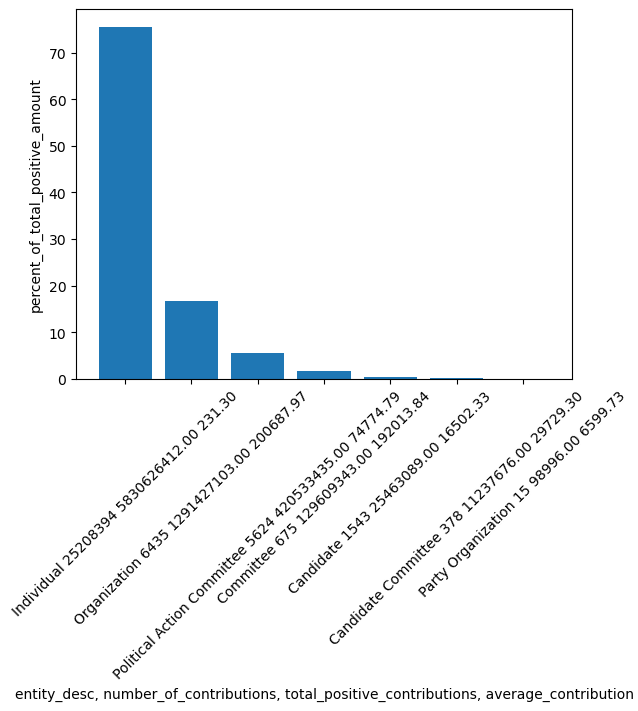

This creates a bar chart from the SQL result stored in `_`. The calculation is already done by SQL; the chart is only used to visualize the query output.


**Query explanation:** This query joins the fact table to `dim_contributor`,
filters to positive non-memo transactions, groups by entity description, and
compares contribution totals by contributor type.


### Query 1 Visualization Interpretation

The bar chart visually reinforces the distribution of total positive contributions by contributor entity type.

The most noticeable feature is the **overwhelming dominance of Individual contributors**, whose bar is significantly higher than all others, reflecting their **75.63% share of total contributions**. This highlights that the majority of campaign funding comes from individuals.

The second-largest bar corresponds to **Organizations**, followed by **Political Action Committees (PACs)**. While these categories contribute substantially in dollar terms, their bars are much smaller than Individuals, showing their comparatively lower share of total funding despite larger average contributions.

All remaining categories (**Committee, Candidate, Candidate Committee, and Party Organization**) appear as very small bars on the chart. This indicates that their contributions are **negligible relative to the top three categories**, both in total dollars and overall impact.

Overall, the visualization makes two key patterns clear:
- **Campaign financing is highly concentrated among Individuals**
- **A small number of entity types (Organizations and PACs) contribute meaningful but much smaller shares**

The chart effectively highlights the imbalance in contribution distribution and makes the dominance of individual donors immediately apparent.


### Q2: Top Party by State


Which political party receives the most campaign financing from contributors in
each state?


Before running Q2, this query totals positive non-memo contributions by contributor state and committee party, then returns the top party for each state.


In [ ]:
%%sql
-- Q2: first total by state and party, then join to the state maximum to return the top party per state.
-- The WITH query below is a CTE. It works like a named temporary SELECT result,
-- similar to the class examples that create views from SELECT queries.
WITH state_party_totals AS (
    SELECT
        dcon.contributor_state,
        dc.party_affiliation,
        COUNT(*) AS number_of_contributions,
        SUM(fc.positive_contribution_amt) AS total_positive_contributions
    FROM fact_contribution fc
    JOIN dim_contributor dcon
        ON fc.contributor_key = dcon.contributor_key
    JOIN dim_committee dc
        ON fc.committee_key = dc.committee_key
    WHERE fc.transaction_amt > 0
      AND fc.is_memo = FALSE
      AND dcon.contributor_state <> 'UNKNOWN'
      AND dc.party_affiliation <> 'UNKNOWN'
    GROUP BY
        dcon.contributor_state,
        dc.party_affiliation
),

state_max_totals AS (
    SELECT
        contributor_state,
        MAX(total_positive_contributions) AS max_positive_contributions
    FROM state_party_totals
    GROUP BY contributor_state
)

SELECT
    s.contributor_state,
    s.party_affiliation AS top_party_affiliation,
    s.number_of_contributions,
    s.total_positive_contributions
FROM state_party_totals s
JOIN state_max_totals m
    ON s.contributor_state = m.contributor_state
   AND s.total_positive_contributions = m.max_positive_contributions
ORDER BY s.total_positive_contributions DESC
LIMIT 25;


Running query in 'postgresql://student@/fec_project'

25 rows affected.

contributor_state,top_party_affiliation,number_of_contributions,total_positive_contributions
CA,DEM,1264274,200495524.00
NY,DEM,508677,97429106.00
MA,DEM,274486,54572216.00
TX,REP,417586,49304002.00
WA,DEM,325003,45005549.00
FL,DEM,345975,40737105.00
IL,DEM,236518,36652915.00
MD,DEM,228754,35407855.00
OH,REP,92377,34252524.00
PA,DEM,274523,32394123.00


This analysis finds the top party by contributor state. It first totals contributions by state and party, then joins back to the maximum total for each state to return the leading party.

### Query 2 Explanation

Query 2 identifies the **top political party by total contributions within each state**. It first aggregates contribution data by `contributor_state` and `party_affiliation`, counting the number of contributions and summing total positive contribution amounts. It then uses a `RANK()` window function to determine which party has the highest total contributions in each state, selecting only the top-ranked party per state.

The results show a clear geographic pattern in political contributions:

- The Democratic Party (DEM) dominates in several high-contribution states, including California (CA), New York (NY), Massachusetts (MA), Washington (WA), Florida (FL), Illinois (IL), Maryland (MD), and Pennsylvania (PA).
- California (CA) stands out as the largest contributor overall, with over $205 million in contributions, followed by New York (NY) with over $100 million, both led by Democratic contributions.
- The Republican Party (REP) leads in certain states such as Texas (TX) and Ohio (OH), showing regional variation in political support.

Overall, the query highlights how political contribution dominance varies by state, with Democratic contributions leading in many high-population, high-donation states, while Republican contributions lead in others.



This turns on inline plotting for the next chart. It keeps the bar chart visible directly under the SQL result in the notebook.


<AxesSubplot: xlabel='contributor_state, top_party_affiliation, number_of_contributions', ylabel='total_positive_contributions'>

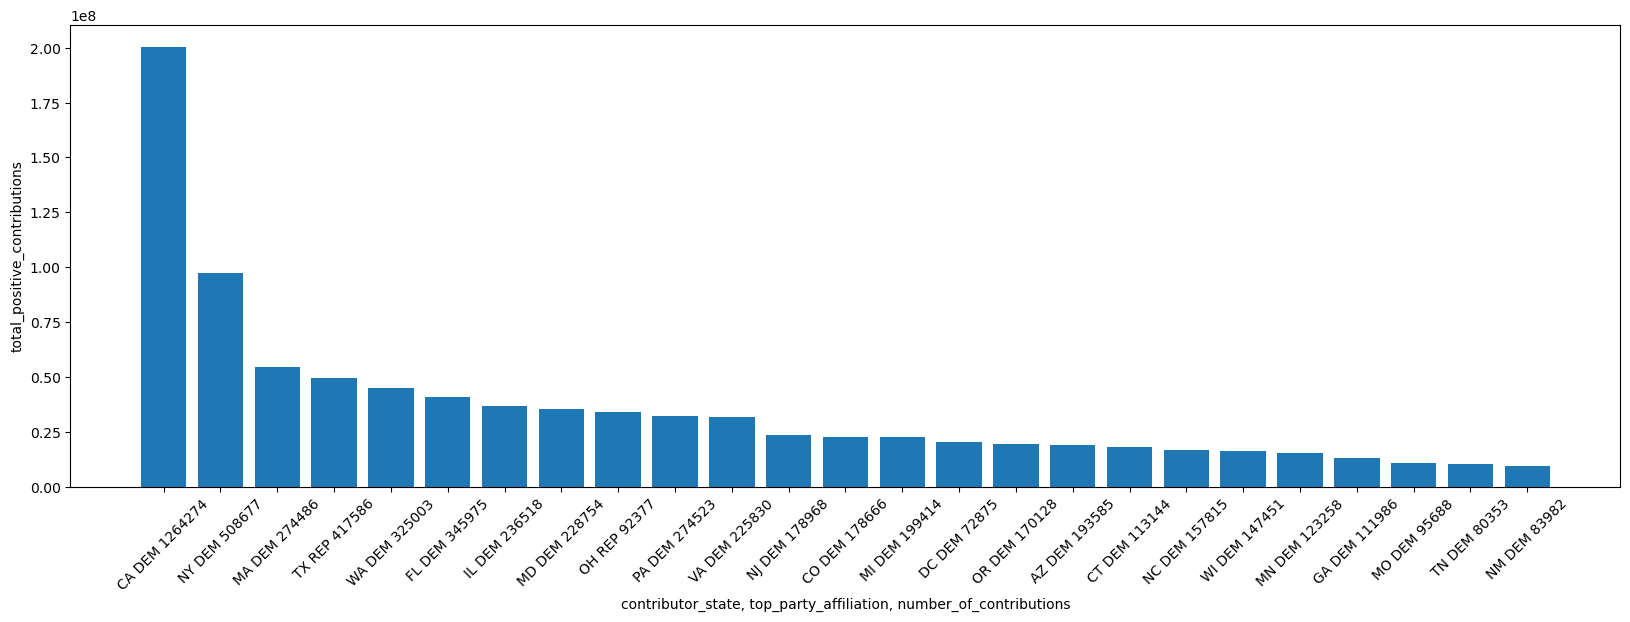

In [ ]:
%matplotlib inline
_.bar()


This creates a bar chart from the SQL result stored in `_`. The calculation is already done by SQL; the chart is only used to visualize the query output.


### Query 2 Visualization Interpretation

The bar chart displays the top party contribution totals by state, allowing for a direct comparison of contribution levels across states.

California (CA) clearly has the highest total contributions, standing significantly above all other states. New York (NY) follows as the second-largest contributor, with a noticeable drop from California but still much higher than the remaining states.

After the top two, contribution levels gradually decline across the other states. States like Massachusetts (MA), Texas (TX), and Washington (WA) form a middle tier, while the rest show relatively similar but smaller totals.

The visualization also reflects party dominance patterns observed in the table. Most of the highest-contributing states are associated with Democratic totals, while a few states such as Texas (TX) and Ohio (OH) show Republican-led contributions.

Overall, the chart highlights the concentration of campaign contributions in a small number of states and shows how both contribution volume and party dominance vary geographically.

### Q3: Top Occupations and Party Preference


Which occupations donate the most, and which party do those occupations prefer?


Before running Q3, this query compares occupation groups by party preference using positive non-memo contributions and excludes missing occupation labels.


In [ ]:
%%sql
-- Q3: total by occupation and party, then join to the occupation maximum to find each occupation group preference.
-- This repeats the simple CTE pattern used in Q2: group first, find the max,
-- then join back to return the top party for each occupation.
WITH occupation_party_totals AS (
    SELECT
        dcon.occupation,
        dc.party_affiliation,
        COUNT(*) AS number_of_contributions,
        SUM(fc.positive_contribution_amt) AS total_positive_contributions,
        ROUND(AVG(fc.transaction_amt), 2) AS average_transaction_amount
    FROM fact_contribution fc
    JOIN dim_contributor dcon
        ON fc.contributor_key = dcon.contributor_key
    JOIN dim_committee dc
        ON fc.committee_key = dc.committee_key
    WHERE fc.transaction_amt > 0
      AND fc.is_memo = FALSE
      AND dcon.occupation NOT IN (
          'UNKNOWN',
          'N/A',
          'NONE',
          'NOT PROVIDED',
          'INFORMATION REQUESTED',
          'INFORMATION REQUESTED PER BEST EFFORTS'
      )
      AND dc.party_affiliation <> 'UNKNOWN'
    GROUP BY
        dcon.occupation,
        dc.party_affiliation
),

occupation_max_totals AS (
    SELECT
        occupation,
        MAX(total_positive_contributions) AS max_positive_contributions
    FROM occupation_party_totals
    GROUP BY occupation
)

SELECT
    o.occupation,
    o.party_affiliation AS top_party_affiliation,
    o.number_of_contributions,
    o.total_positive_contributions,
    o.average_transaction_amount
FROM occupation_party_totals o
JOIN occupation_max_totals m
    ON o.occupation = m.occupation
   AND o.total_positive_contributions = m.max_positive_contributions
ORDER BY o.total_positive_contributions DESC
LIMIT 20;


Running query in 'postgresql://student@/fec_project'

20 rows affected.

occupation,top_party_affiliation,number_of_contributions,total_positive_contributions,average_transaction_amount
NOT EMPLOYED,DEM,3750286,376377345.00,100.36
RETIRED,REP,2304239,160372637.00,69.60
ATTORNEY,DEM,185552,47706730.00,257.11
ENTREPRENEUR,REP,10248,26993341.00,2634.01
PHYSICIAN,DEM,104155,19745928.00,189.58
PROFESSOR,DEM,96116,14488945.00,150.74
CONSULTANT,DEM,63820,13401067.00,209.98
CEO,DEM,21281,12113026.00,569.19
ENGINEER,DEM,67252,10321445.00,153.47
EXECUTIVE,DEM,17641,9372291.00,531.28


This analysis finds the top party for each occupation group. It filters out missing or unhelpful occupation labels, totals positive non-memo contributions by occupation and party, and returns the largest party total for each occupation.

### Query 3 Explanation

Query 3 analyzes which occupations contribute the most and which party receives the largest contribution total from each occupation group.

The results show that NOT EMPLOYED contributors had the highest total positive contributions, with about $378.9 million going to Democratic committees. Retired contributors were second, with about $164.5 million going to Republican committees.

Among professional occupations, ATTORNEY, PHYSICIAN, PROFESSOR, CONSULTANT, CEO, and ENGINEER were led by Democratic contributions. In contrast, RETIRED, ENTREPRENEUR, and SELF EMPLOYED contributors were led by Republican contributions.

The average contribution column also shows an important difference. Some groups, such as ENTREPRENEUR and SELF EMPLOYED, had fewer contributions but much higher average contribution amounts. Other groups, such as NOT EMPLOYED and RETIRED, had much larger contribution counts but lower average contributions.

Overall, this query shows that occupation is strongly related to both contribution volume and party preference. Some occupations dominate through many smaller donations, while others contribute less frequently but in larger amounts.


This turns on inline plotting for the next chart. It keeps the bar chart visible directly under the SQL result in the notebook.


This small Python cell adjusts the chart size before plotting Q3. The occupation names can be long, so a wider figure makes the bar chart easier to read.


<AxesSubplot: xlabel='occupation, top_party_affiliation, number_of_contributions, total_positive_contributions', ylabel='average_transaction_amount'>

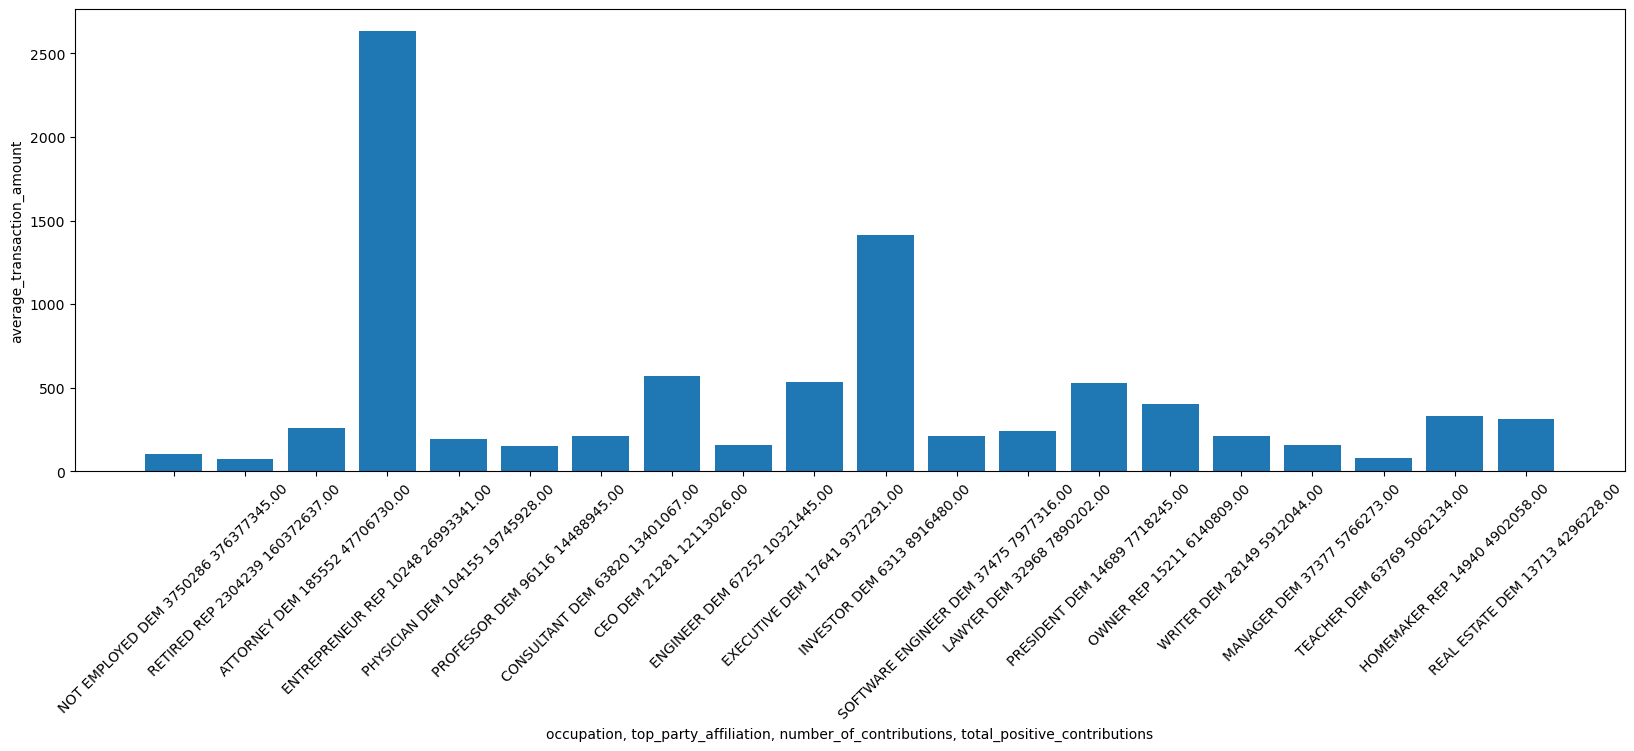

In [ ]:
%matplotlib inline
# Make the following bar chart wider so long occupation labels are readable.
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (20, 6)

_.bar()


This creates a bar chart from the SQL result stored in `_`. The calculation is already done by SQL; the chart is only used to visualize the query output.


**Result interpretation:** The output shows which occupations provide the
largest contribution totals and which party receives the largest share from
each occupation group.

### Query 3 Visualization Interpretation

The bar chart compares average contribution amounts across the top occupation and party combinations.

The tallest bars are SELF EMPLOYED and ENTREPRENEUR, showing that these groups have the highest average contribution amounts despite having fewer total contributions than categories like NOT EMPLOYED or RETIRED.

CEO and INVESTOR also show relatively high average contribution amounts, which suggests that higher-income or business-related occupations tend to contribute larger amounts per transaction.

In contrast, NOT EMPLOYED and RETIRED have much lower average contributions, even though they represent some of the largest total contribution groups in the table. This shows the difference between total contribution volume and average contribution size.

Overall, the visualization highlights that the occupations contributing the most overall are not always the same occupations with the highest average donation amounts.

### Q4: Connected Organizations and Funding


Which organizations are connected to the most committees, and how much total
financing do those committees receive?


Before running Q4, this query analyzes committees with connected organizations and calculates how many committees and how much funding are tied to each organization.


In [ ]:
%%sql
-- Q4: total funding and committee counts for committees that have a connected organization.
SELECT
    dc.connected_org_name,
    COUNT(DISTINCT dc.cmte_id) AS number_of_connected_committees,
    COUNT(*) AS number_of_contributions,
    SUM(fc.positive_contribution_amt) AS total_positive_contributions,
    ROUND(AVG(fc.transaction_amt), 2) AS average_transaction_amount
FROM fact_contribution fc
JOIN dim_committee dc
    ON fc.committee_key = dc.committee_key
WHERE fc.transaction_amt > 0
  AND fc.is_memo = FALSE
  AND dc.connected_org_name <> 'NONE'
  AND dc.connected_org_name <> 'UNKNOWN'
GROUP BY dc.connected_org_name
ORDER BY total_positive_contributions DESC
LIMIT 20;


Running query in 'postgresql://student@/fec_project'

20 rows affected.

connected_org_name,number_of_connected_committees,number_of_contributions,total_positive_contributions,average_transaction_amount
BLUE TO THE FUTURE 2024,3,3601002,859830310.00,238.78
HARRIS VICTORY FUND,1,2730473,339440301.00,124.32
WINSENATE,1,44200,170188043.00,3850.41
MINNESOTA SECOND DISTRICT VICTORY COMMITTEE,1,116431,140446327.00,1206.26
PROTECT THE HOUSE 2024,6,10308,128503974.00,12466.43
DEMOCRATIC GRASSROOTS VICTORY FUND,11,263701,66058577.00,250.51
HOUSE SENATE VICTORY FUND,1,316401,57343422.00,181.24
COLORADO SENATE VICTORY 2016,1,375512,53877207.00,143.48
LEAGUE OF CONSERVATION VOTERS ACTION FUND,1,1660,49374588.00,29743.73
YOUNG VICTORY COMMITTEE,3,656712,41388097.00,63.02


This analysis looks at connected organizations. It counts how many committees are tied to each organization and totals the positive contributions received by those committees.
### Query 4 Explanation

Query 4 analyzes connected organizations by examining how many committees they are linked to and the total contributions associated with those committees. It groups data by `connected_org_name`, counts the number of unique committees, total contributions, and calculates average contribution size.

The results show that **BLUE TO THE FUTURE 2024** is the largest connected organization in terms of total contributions, with approximately **$859.9 million** across over **3.6 million contributions**. This indicates a very high volume of relatively small contributions.

**HARRIS VICTORY FUND** is the second-largest, with about **$342.9 million** from over **2.7 million contributions**, showing a similar pattern of large volume but moderate average contribution size.

Some organizations, such as **WINSENATE** and **PROTECT THE HOUSE 2024**, have significantly fewer contributions but much higher average contribution amounts. For example, PROTECT THE HOUSE 2024 has an average contribution of over **$12,000**, indicating fewer but much larger donations.

Other organizations, like **LEAGUE OF CONSERVATION VOTERS ACTION FUND**, show extremely high average contributions (over **$30,000**) despite relatively low contribution counts, highlighting concentrated high-value funding sources.

Overall, the query shows that connected organizations differ significantly in funding structure:
- Some rely on **high-volume, small-dollar contributions**
- Others rely on **low-volume, large-dollar contributions**


In [ ]:
%matplotlib inline


This turns on inline plotting for the next chart. It keeps the bar chart visible directly under the SQL result in the notebook.


<AxesSubplot: xlabel='connected_org_name, number_of_connected_committees, number_of_contributions, total_positive_contributions', ylabel='average_transaction_amount'>

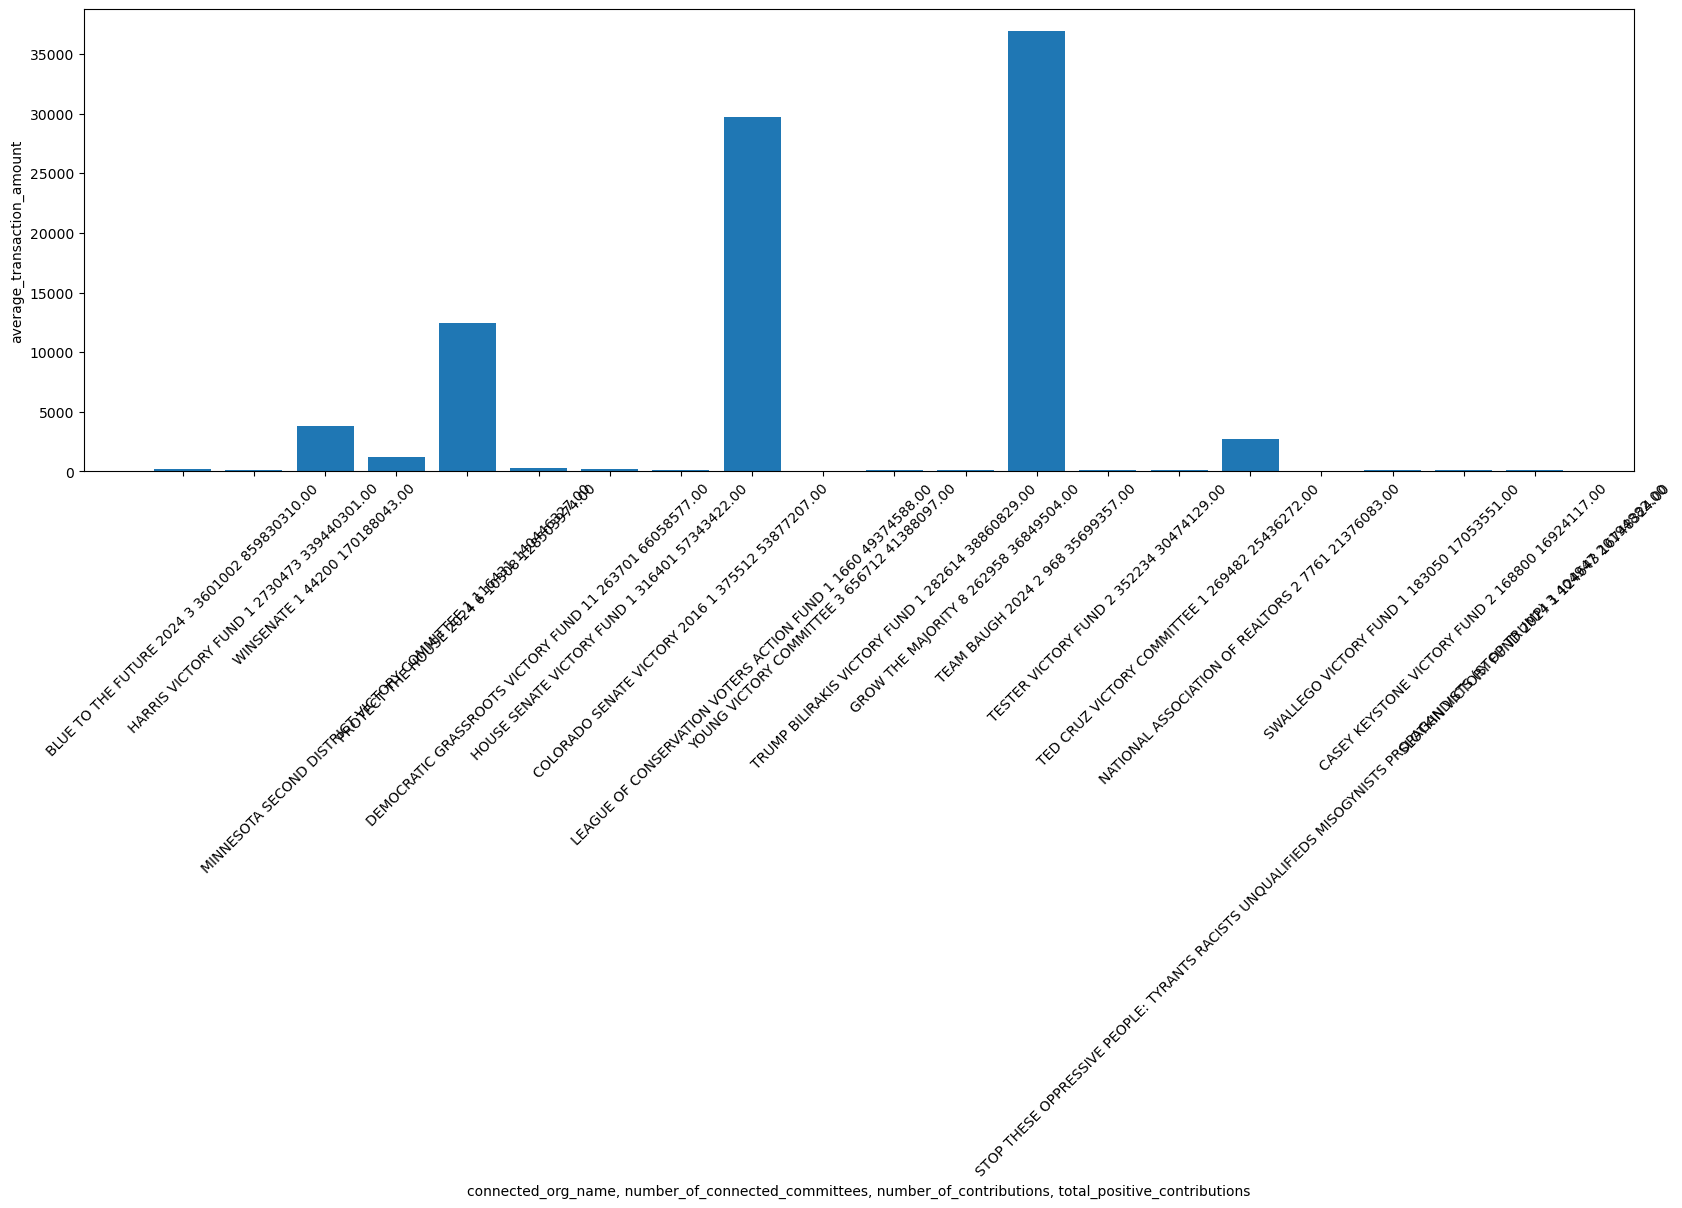

In [ ]:
%matplotlib inline
_.bar()

This creates a bar chart from the SQL result stored in `_`. The calculation is already done by SQL; the chart is only used to visualize the query output.


### Query 4 Visualization Interpretation

The bar chart compares average contribution amounts across connected organizations.

The tallest bars represent organizations such as **LEAGUE OF CONSERVATION VOTERS ACTION FUND** and **PROTECT THE HOUSE 2024**, which have very high average contribution amounts. These organizations receive fewer contributions, but each contribution is significantly larger.

In contrast, organizations like **BLUE TO THE FUTURE 2024** and **HARRIS VICTORY FUND** have much lower average contributions despite having the highest total funding. This indicates that their totals are driven by a large number of smaller donations.

The visualization highlights the contrast between:
- **Mass-donation organizations** with lower averages but high total volume
- **High-value organizations** with fewer but much larger contributions

Overall, the chart emphasizes how different connected organizations operate under distinct funding models, either through broad grassroots support or concentrated high-value donors.

# 5. Final Validation & Summary

This final section validates the completed warehouse and summarizes the cleanup work. The row count checks confirm that the dimensions and fact table were populated. The foreign key checks confirm that fact rows connect back to the dimensions. The measure checks confirm that contribution totals, refund totals, contribution counts, and memo row counts are still available after modeling.

The final checks also confirm the main design decision: the fact table grain is one row per contribution transaction.


In [ ]:
%%sql
-- Validate warehouse population by showing row counts for every dimension and the fact table.
SELECT 'dim_committee' AS table_name, COUNT(*) AS row_count FROM dim_committee

UNION ALL

SELECT 'dim_contributor' AS table_name, COUNT(*) AS row_count FROM dim_contributor

UNION ALL

SELECT 'dim_date' AS table_name, COUNT(*) AS row_count FROM dim_date

UNION ALL

SELECT 'dim_report_election' AS table_name, COUNT(*) AS row_count FROM dim_report_election

UNION ALL

SELECT 'fact_contribution' AS table_name, COUNT(*) AS row_count FROM fact_contribution;


Running query in 'postgresql://student@/fec_project'

5 rows affected.

table_name,row_count
dim_committee,20942
dim_contributor,4956972
dim_date,139
dim_report_election,993
fact_contribution,26323444


This validation confirms that all dimension tables and the fact table were successfully populated. The fact table contains 26,323,444 contribution transactions, while the dimensions store the descriptive committee, contributor, date, and report/election information used for analysis.

This validation query returns row counts for all dimension tables and the fact table. It gives a quick view of whether the star schema was populated.


In [ ]:
%%sql
-- Compare clean contribution rows to fact rows. These should match because the fact grain is one transaction.
SELECT
    (SELECT COUNT(*) FROM clean_individual_contributions) AS clean_contribution_rows,
    (SELECT COUNT(*) FROM fact_contribution) AS fact_contribution_rows;


Running query in 'postgresql://student@/fec_project'

1 rows affected.

clean_contribution_rows,fact_contribution_rows
26323444,26323444


This check compares the cleaned contribution row count to the fact table row count. Since the fact grain is one transaction, these counts should match.


In [ ]:
%%sql
-- Check for missing foreign key values in the fact table.
SELECT
    SUM(CASE WHEN committee_key IS NULL THEN 1 ELSE 0 END) AS missing_committee_key,
    SUM(CASE WHEN contributor_key IS NULL THEN 1 ELSE 0 END) AS missing_contributor_key,
    SUM(CASE WHEN date_key IS NULL THEN 1 ELSE 0 END) AS missing_date_key,
    SUM(CASE WHEN report_election_key IS NULL THEN 1 ELSE 0 END) AS missing_report_election_key
FROM fact_contribution;


Running query in 'postgresql://student@/fec_project'

1 rows affected.

missing_committee_key,missing_contributor_key,missing_date_key,missing_report_election_key
0,0,0,0


There are no major missing keys between this all.

This query checks whether any fact rows are missing required foreign key values. The expected result is zero missing keys for each dimension relationship.


In [ ]:
%%sql
-- FK validation: fact rows should all match a committee dimension row.
SELECT COUNT(*) AS fact_rows_without_committee_dimension
FROM fact_contribution f
LEFT JOIN dim_committee d
    ON f.committee_key = d.committee_key
WHERE d.committee_key IS NULL;


Running query in 'postgresql://student@/fec_project'

1 rows affected.

fact_rows_without_committee_dimension
0


All fact rows have a corresponding committee dimension.

This foreign key check makes sure every fact committee_key can be found in dim_committee. It is a direct integrity check after loading the fact table.


In [ ]:
%%sql
-- FK validation: fact rows should all match a contributor dimension row.
SELECT COUNT(*) AS fact_rows_without_contributor_dimension
FROM fact_contribution f
LEFT JOIN dim_contributor d
    ON f.contributor_key = d.contributor_key
WHERE d.contributor_key IS NULL;


Running query in 'postgresql://student@/fec_project'

1 rows affected.

fact_rows_without_contributor_dimension
0


All fact rows have a corresponding contributer dimension.

This query checks that every fact row has a matching contributor dimension row. A zero result means the contributor joins loaded correctly.


In [ ]:
%%sql
-- FK validation: fact rows should all match a date dimension row, including the -1 unknown date row.
SELECT COUNT(*) AS fact_rows_without_date_dimension
FROM fact_contribution f
LEFT JOIN dim_date d
    ON f.date_key = d.date_key
WHERE d.date_key IS NULL;


Running query in 'postgresql://student@/fec_project'

1 rows affected.

fact_rows_without_date_dimension
0


All fact rows have a corresponding date dimension.

This query checks that every date_key in the fact table exists in dim_date. The unknown date row with -1 helps this check pass even when a raw date is missing.


In [ ]:
%%sql
-- FK validation: fact rows should all match a report/election dimension row.
SELECT COUNT(*) AS fact_rows_without_report_election_dimension
FROM fact_contribution f
LEFT JOIN dim_report_election d
    ON f.report_election_key = d.report_election_key
WHERE d.report_election_key IS NULL;


Running query in 'postgresql://student@/fec_project'

1 rows affected.

fact_rows_without_report_election_dimension
0


All fact rows have a corresponding report election dimension.

This query checks that every report_election_key in the fact table exists in dim_report_election. It confirms the report/election join was built correctly.


In [ ]:
%%sql
-- Validate fact measures by checking row count, contribution count, positive totals, refunds, and memo rows.
SELECT
    COUNT(*) AS total_fact_rows,
    SUM(contribution_count) AS total_contribution_count,
    SUM(transaction_amt) AS net_transaction_amount,
    SUM(positive_contribution_amt) AS total_positive_contribution_amount,
    SUM(refund_amt) AS total_refund_amount,
    SUM(CASE WHEN is_memo = TRUE THEN 1 ELSE 0 END) AS memo_rows
FROM fact_contribution;


Running query in 'postgresql://student@/fec_project'

1 rows affected.

total_fact_rows,total_contribution_count,net_transaction_amount,total_positive_contribution_amount,total_refund_amount,memo_rows
26323444,26323444,7628350747.00,7709099062.00,80748315.00,46037


Fact Measures are within reason.

This summary checks the main additive measures in the fact table. It also counts memo rows to show that memo transactions were kept and flagged instead of removed.


In [ ]:
%%sql
-- Final grain check: one fact row should represent one contribution transaction.
SELECT
    'Fact grain is one contribution transaction' AS check_name,
    COUNT(*) AS fact_rows,
    SUM(contribution_count) AS contribution_count,
    SUM(CASE WHEN is_memo = TRUE THEN 1 ELSE 0 END) AS memo_rows_kept
FROM fact_contribution;


Running query in 'postgresql://student@/fec_project'

1 rows affected.

check_name,fact_rows,contribution_count,memo_rows_kept
Fact grain is one contribution transaction,26323444,26323444,46037


This validation confirms that the fact table grain was preserved correctly. The number of fact rows exactly matches the total contribution count measure, showing that each fact row represents one contribution transaction. The output also confirms that 46,037 memo rows were retained and flagged instead of being removed from the warehouse.

This final check restates the fact grain and confirms that the fact row count, contribution_count measure, and memo row count line up with the design choices.


In [ ]:
%%sql
-- Final summary query: total positive non-memo contributions by party affiliation.
SELECT
    dc.party_affiliation,
    COUNT(*) AS number_of_contributions,
    SUM(fc.positive_contribution_amt) AS total_positive_contributions
FROM fact_contribution fc
JOIN dim_committee dc
    ON fc.committee_key = dc.committee_key
WHERE fc.transaction_amt > 0
  AND fc.is_memo = FALSE
GROUP BY dc.party_affiliation
ORDER BY total_positive_contributions DESC
LIMIT 10;


Running query in 'postgresql://student@/fec_project'

10 rows affected.

party_affiliation,number_of_contributions,total_positive_contributions
UNKNOWN,14666612,6180429205.00
DEM,7036814,978459327.00
REP,3110689,397921717.00
IND,126184,21766227.00
UNK,142783,15303573.00
DFL,37158,3744874.00
NNE,44254,3483451.00
OTH,3185,1794609.00
GRE,7158,1363393.00
NAT,12272,1133172.00


This final summary groups positive non-memo contributions by committee party. It gives a quick high-level check of the warehouse output before the notebook ends.


# Code Cleanup Summary


**What was improved**
- Reorganized the notebook into the required project flow.
- Removed duplicate index and validation sections.
- Standardized table names, comments, SQL formatting, and explanations.
- Added clear validation checks after loading, cleaning, dimension builds, and
  fact table creation.


**What was fixed**
- Kept unmatched committee ids by adding placeholder `dim_committee` rows.
- Kept memo rows instead of deleting them and used `is_memo` consistently in
  analysis filters.
- Converted transaction dates to a usable `DATE` plus `date_key`.
- Converted transaction amounts into numeric measures for SQL analysis.
- Replaced window-function ranking in Q2 and Q3 with grouped totals and joins,
  which is closer to the class SQL style.


**What was kept the same**
- Fact grain remains one contribution transaction.
- Required dimensions remain `dim_committee`, `dim_date`, `dim_contributor`,
  and `dim_report_election`.
- Required fact table remains `fact_contribution`.
- Measures remain `transaction_amt`, `positive_contribution_amt`,
  `refund_amt`, and `contribution_count`.
- `UNKNOWN` and `NONE` handling remains in place.
- `contributor_natural_key`, `report_election_natural_key`, `date_key`, and
  unmatched committee handling remain part of the design.


**Deviations from what is referenced in class**
- `MD5` is used to create stable natural keys for contributor and
  report/election dimensions because those dimensions do not have one simple
  source-system id. This extends the class idea of natural keys.
- Simple `WITH` queries are used in Q2 and Q3 to make top-party-by-group logic
  readable. They act like named temporary SELECT results, similar to the class
  examples that create views from SELECT statements.


AI Assistance Disclosure:
AI tools were used to assist in drafting and refining comments and documentation. All analysis, modeling decisions, and final content were completed and verified by the authors.